# S6E10 | More Aux Carriers | LB 0.96147

> **Part 6 of a series.** [Part 1 (LB 0.96108)](https://www.kaggle.com/code/goodpjw2008/s6e10-route-id-fe-og-model-stack-lb-0-96108) found the two feature ideas. [Part 2 (LB 0.96125)](https://www.kaggle.com/code/goodpjw2008/s6e10-two-view-gbdt-realmlp-stack-lb-0-96125) added a second feature view and a RealMLP schedule. [Part 3 (LB 0.96127)](https://www.kaggle.com/code/goodpjw2008/s6e10-catboost-ctr-glm-margin-xgb-lb-0-96127) measured why the score had stopped moving. [Part 4 (LB 0.96129)](https://www.kaggle.com/code/goodpjw2008/s6e10-auxiliary-task-features-lb-0-96129) found the auxiliary-task features: every column predicted from the other 20. [Part 5 (LB 0.96141)](https://www.kaggle.com/code/goodpjw2008/s6e10-realmlp-aux-task-features-lb-0-96141) gave them to the other model families and found that the weakest member carries them best. This part adds **nine more carriers** and reports **twelve ways of making the features "smarter" that all made things worse**.

**Public LB 0.96147 · nested 5-fold CV 0.96176** — 38 models on one shared fold split, combined by logistic regression on logits.

**The whole notebook in one picture.** The numbers are from our local run, and each panel names the section that derives them. The drawing code is in the hidden cell.

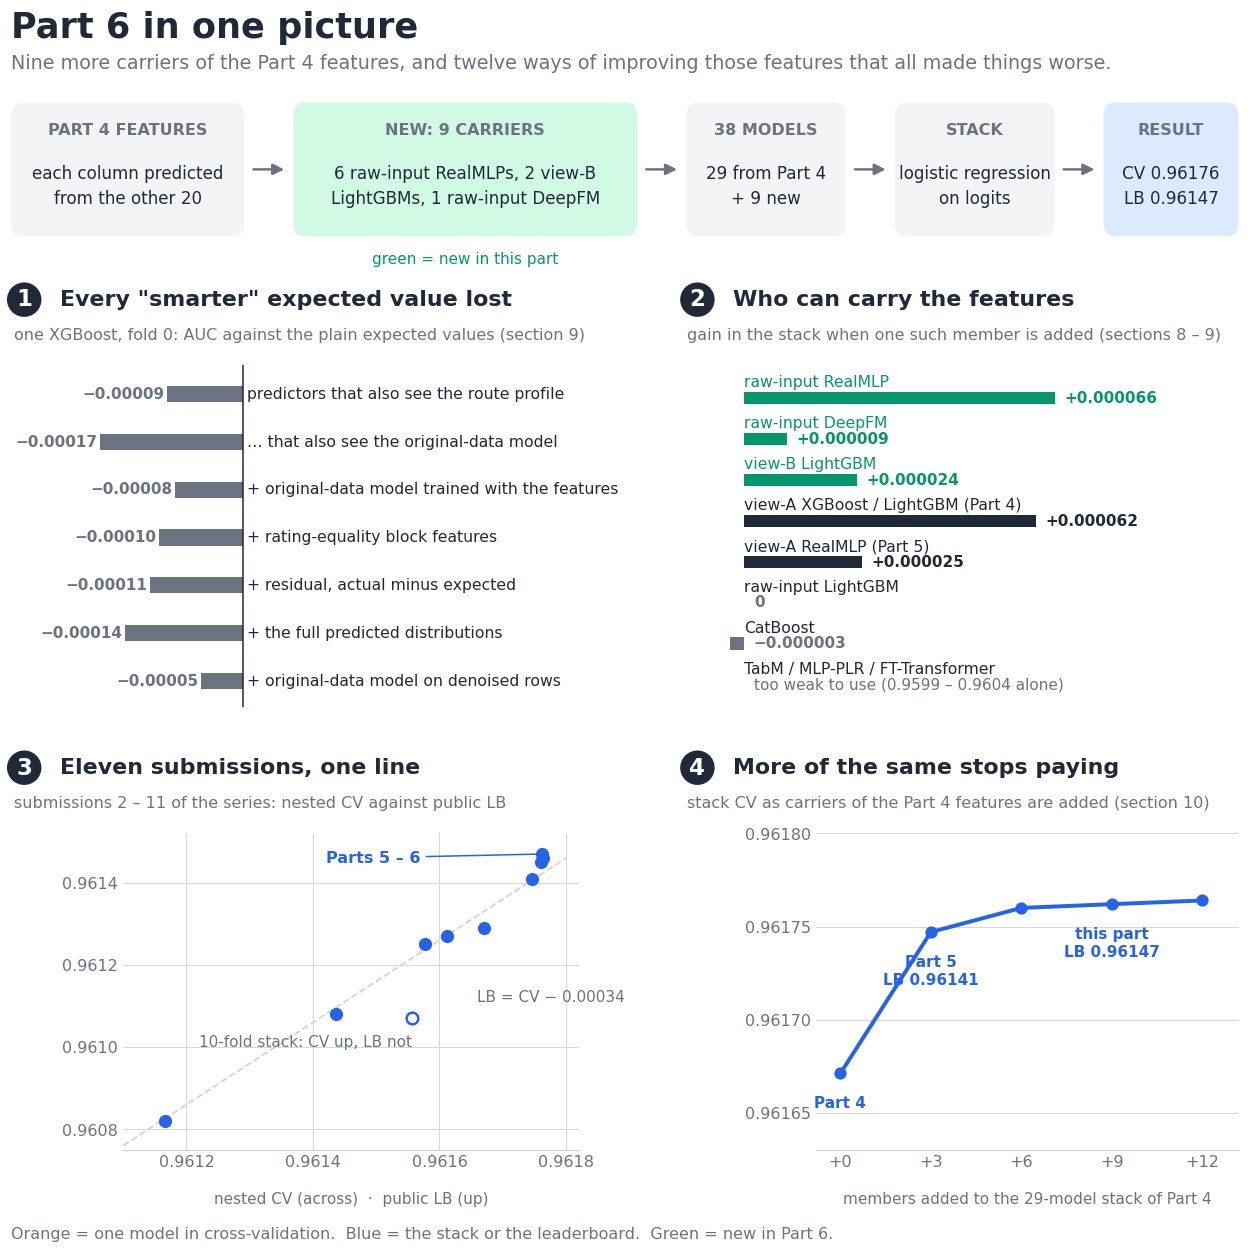

In [1]:
# The whole notebook in one picture.  Every number is from our local run and is derived in
# the section named in each panel; nothing here is computed by this cell.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

INK, MUTED, RULE, CARD = "#1f2937", "#6b7280", "#d1d5db", "#f3f4f6"
SEEN, REAL, NEW = "#f59e0b", "#2563eb", "#059669"  # one model in CV / the stack or the leaderboard / new here
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11, "text.color": INK,
                     "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED})
fig = plt.figure(figsize=(12, 11.5), dpi=110, facecolor="white")
fig.text(0.04, 0.972, "Part 6 in one picture", fontsize=23, fontweight="bold", va="center")
fig.text(0.04, 0.944, "Nine more carriers of the Part 4 features, and twelve ways of improving those features "
         "that all made things worse.", fontsize=12.5, color=MUTED, va="center")

# ---------------------------------------------------------------- the pipeline
ax = fig.add_axes([0.04, 0.80, 0.93, 0.12]); ax.set_xlim(0, 100); ax.set_ylim(0, 10); ax.axis("off")
boxes = [(0.0, 19.0, "PART 4 FEATURES", "each column predicted\nfrom the other 20", CARD),
         (23.0, 28.0, "NEW: 9 CARRIERS", "6 raw-input RealMLPs, 2 view-B\nLightGBMs, 1 raw-input DeepFM", "#d1fae5"),
         (55.0, 13.0, "38 MODELS", "29 from Part 4\n+ 9 new", CARD),
         (72.0, 13.0, "STACK", "logistic regression\non logits", CARD),
         (89.0, 11.0, "RESULT", "CV 0.96176\nLB 0.96147", "#dbeafe")]
for x, w, head, body, col in boxes:
    ax.add_patch(FancyBboxPatch((x, 0.6), w, 8.8, boxstyle="round,pad=0,rounding_size=0.9", fc=col, ec="none"))
    ax.text(x + w / 2, 7.6, head, ha="center", va="center", fontsize=10.5, fontweight="bold", color=MUTED)
    ax.text(x + w / 2, 3.9, body, ha="center", va="center", fontsize=11, linespacing=1.45)
for (x, w, *_), (x2, *_) in zip(boxes[:-1], boxes[1:]):
    ax.add_patch(FancyArrowPatch((x + w + 0.5, 5), (x2 - 0.5, 5), arrowstyle="-|>", mutation_scale=15, color=MUTED, lw=1.6))
ax.text(37.0, -0.9, "green = new in this part", ha="center", va="center", fontsize=10, color=NEW)


def panel(x, y, w, h, pad, no, title, sub):
    """A titled chart area; `pad` leaves room for tick labels left of the axes."""
    fig.text(x, y + h + 0.052, f"{no}", fontsize=15, fontweight="bold", color="white", va="center", ha="center",
             bbox=dict(boxstyle="circle,pad=0.25", fc=INK, ec="none"))
    fig.text(x + 0.027, y + h + 0.052, title, fontsize=14.5, fontweight="bold", va="center")
    fig.text(x - 0.008, y + h + 0.024, sub, fontsize=10.5, color=MUTED, va="center")
    a = fig.add_axes([x + pad, y, w - pad, h])
    for s in ("top", "right"):
        a.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        a.spines[s].set_color(RULE)
    a.tick_params(length=0, labelsize=10.5)
    return a


gain = lambda v: ("+" if v > 0 else "−" if v < 0 else "") + f"{abs(v):.5f}"

# ---------------------------------------------------------------- 1. the plain expected value beats every "better" version
a = panel(0.05, 0.435, 0.42, 0.27, 0.0, 1, "Every \"smarter\" expected value lost",
          "one XGBoost, fold 0: AUC against the plain expected values (section 9)")
neg = [("predictors that also see the route profile", -0.00009), ("… that also see the original-data model", -0.00017),
       ("+ original-data model trained with the features", -0.00008), ("+ rating-equality block features", -0.00010),
       ("+ residual, actual minus expected", -0.00011), ("+ the full predicted distributions", -0.00014),
       ("+ original-data model on denoised rows", -0.00005)]
for i, (lab, v) in enumerate(neg):
    a.barh(i, v, height=0.34, color=MUTED)
    a.text(0.000005, i, lab, va="center", fontsize=10.2)
    a.text(v - 0.000003, i, gain(v), va="center", ha="right", fontsize=10, color=MUTED, fontweight="bold")
a.axvline(0, color=INK, lw=1); a.set_ylim(len(neg) - 0.45, -0.6); a.set_xlim(-0.00026, 0.00040)
a.set_yticks([]); a.set_xticks([]); a.spines["left"].set_visible(False); a.spines["bottom"].set_visible(False)

# ---------------------------------------------------------------- 2. which families carry the features
a = panel(0.56, 0.435, 0.41, 0.27, 0.0, 2, "Who can carry the features",
          "gain in the stack when one such member is added (sections 8 – 9)")
car = [("raw-input RealMLP", 0.000066, NEW), ("raw-input DeepFM", 0.000009, NEW), ("view-B LightGBM", 0.000024, NEW),
       ("view-A XGBoost / LightGBM (Part 4)", 0.000062, INK), ("view-A RealMLP (Part 5)", 0.000025, INK),
       ("raw-input LightGBM", 0.0, MUTED), ("CatBoost", -0.000003, MUTED), ("TabM / MLP-PLR / FT-Transformer", None, MUTED)]
for i, (lab, v, col) in enumerate(car):
    a.text(0, i - 0.38, lab, va="center", fontsize=10.2, color=col if col != MUTED else INK)
    if v is None:
        a.text(0.000002, i, "too weak to use (0.9599 – 0.9604 alone)", va="center", fontsize=10, color=MUTED)
    else:
        a.barh(i, v, height=0.3, color=col)
        a.text(max(v, 0) + 0.000002, i, (("+" if v > 0 else "−") + f"{abs(v):.6f}") if v else "0", va="center",
               fontsize=10, color=col, fontweight="bold")
a.set_ylim(len(car) - 0.45, -0.8); a.set_xlim(-0.00001, 0.000105); a.set_yticks([]); a.set_xticks([])
a.spines["bottom"].set_visible(False); a.spines["left"].set_visible(False)

# ---------------------------------------------------------------- 3. CV vs LB over the series
a = panel(0.05, 0.085, 0.42, 0.25, 0.075, 3, "Eleven submissions, one line",
          "submissions 2 – 11 of the series: nested CV against public LB")
cv = [0.958763, 0.961436, 0.961166, 0.961557, 0.961577, 0.961612, 0.961671, 0.961747, 0.961760, 0.961762, 0.961764]
lb = [0.95808, 0.96108, 0.96082, 0.96107, 0.96125, 0.96127, 0.96129, 0.96141, 0.96145, 0.96147, 0.96146]
a.scatter(cv[1:], lb[1:], s=58, color=REAL, zorder=3)
a.scatter(cv[3:4], lb[3:4], s=58, facecolor="white", edgecolor=REAL, linewidth=1.6, zorder=4)
a.plot([0.9611, 0.9618], [0.9611 - 0.00034, 0.9618 - 0.00034], color=RULE, lw=1.2, ls="--", zorder=1)
a.text(0.96166, 0.96111, "LB = CV − 0.00034", fontsize=10, color=MUTED)
a.text(0.961557, 0.96103, "10-fold stack: CV up, LB not", fontsize=10, color=MUTED, ha="right", va="top")
a.annotate("Parts 5 – 6", (0.961762, 0.96147), (0.96142, 0.96145), fontsize=10.5, color=REAL, fontweight="bold",
           arrowprops=dict(arrowstyle="-", color=REAL, lw=1))
a.set_xlim(0.96110, 0.96182); a.set_ylim(0.96075, 0.96152)
a.set_xticks([0.9612, 0.9614, 0.9616, 0.9618]); a.set_xticklabels(["0.9612", "0.9614", "0.9616", "0.9618"])
a.set_yticks([0.9608, 0.9610, 0.9612, 0.9614]); a.set_yticklabels(["0.9608", "0.9610", "0.9612", "0.9614"])
a.grid(color=RULE, lw=0.6); a.set_axisbelow(True); a.spines["left"].set_visible(False)
a.text(0.5, -0.17, "nested CV (across)  ·  public LB (up)", transform=a.transAxes, ha="center", fontsize=10, color=MUTED)

# ---------------------------------------------------------------- 4. saturation
a = panel(0.56, 0.085, 0.41, 0.25, 0.09, 4, "More of the same stops paying",
          "stack CV as carriers of the Part 4 features are added (section 10)")
n = [0, 3, 6, 9, 12]
s = [0.961671, 0.961747, 0.961760, 0.961762, 0.961764]
a.plot(n, s, color=REAL, lw=2.6, marker="o", ms=7)
for x, v, lab in zip(n, s, ["Part 4", "Part 5\nLB 0.96141", "", "this part\nLB 0.96147", ""]):
    if lab:
        a.text(x, v - 0.000012, lab, ha="center", va="top", fontsize=10, color=REAL, fontweight="bold", linespacing=1.3)
a.set_xticks(n); a.set_xticklabels(["+0", "+3", "+6", "+9", "+12"]); a.set_xlim(-0.8, 13.2)
a.set_ylim(0.96163, 0.96180); a.set_yticks([0.96165, 0.96170, 0.96175, 0.96180])
a.set_yticklabels(["0.96165", "0.96170", "0.96175", "0.96180"])
a.grid(axis="y", color=RULE, lw=0.6); a.set_axisbelow(True); a.spines["left"].set_visible(False)
a.text(0.5, -0.17, "members added to the 29-model stack of Part 4", transform=a.transAxes, ha="center", fontsize=10, color=MUTED)

fig.text(0.04, 0.018, "Orange = one model in cross-validation.  Blue = the stack or the leaderboard.  Green = new in Part 6.",
         fontsize=10.5, color=MUTED, va="center")
fig.savefig("part6_summary.png", facecolor="white")
plt.show()

This is a small part, and it says so. The stack moves from 0.961747 to 0.961762 in CV and from 0.96141 to 0.96147 on the leaderboard. What is worth reading is what we measured on the way:

1. **More carriers, diminishing returns.** Six raw-input RealMLPs, two view-B LightGBMs and a raw-input DeepFM, each given the Part 4 features, add +0.000015 on top of Part 5. Going from three such members to twelve moves the stack by +0.000017 in all (section 10).
2. **Every attempt to improve the features failed.** Predictors that also see the route profile, or the original-data model, or the original-data model retrained with the features, residuals, full distributions, the rating-equality blocks of a public notebook: twelve variants, all below the plain expected value on the same fold and seed (section 11). The expected value is best when it knows *only* the other 20 columns.
3. **Who can carry the features.** RealMLP, DeepFM and the view-B trees do; CatBoost, a raw-input LightGBM, TabM, MLP-PLR and FT-Transformer do not (section 10).
4. **Three near-identical submissions.** Stacks whose nested CV differs by 0.000005 scored 0.96145, 0.96147 and 0.96146. That is the noise of the public leaderboard for files that share 99.98% of their ranking, and it is why we stop adding members here.

| step | nested CV | public LB |
|---|---|---|
| Part 1: 13 view-A models | 0.961436 | 0.96108 |
| Part 2: + DeepFM, view-B trees, `flat_anneal` RealMLP (21 models) | 0.961577 | 0.96125 |
| Part 3: + CatBoost with its own categorical statistics ×3, XGBoost from a GLM margin ×2 (26 models) | 0.961612 | 0.96127 |
| Part 4: + 3 trees with auxiliary-task features (29 models) | 0.961671 | 0.96129 |
| Part 5: + 2 raw-input RealMLPs and 1 view-B LightGBM with those features (32 models) | 0.961747 | 0.96141 |
| + 6 more carriers of those features (38 models, this notebook) | **0.961762** | **0.96147** |

> The LB score in the title comes from running this pipeline on our own machine. GPU training is not bit-reproducible, so a re-run can differ in the 5th decimal. Part 5 was published without a Kaggle run (our weekly GPU quota was used up); its full local run matched the submitted stack at 0.961745.

## Scoreboard: what each technique is worth

Carried forward from Parts 1 to 5. Rows marked *(new)* are from this part. Every number is a 5-fold AUC on the same split (`StratifiedKFold(5, shuffle=True, random_state=42)`); stack numbers are nested (the combiner never scores rows it was fitted on). "LB" is the public score of runs we actually submitted.

**One XGBoost, technique by technique**

| technique | CV | gain | LB |
|---|---|---|---|
| raw 21 columns | 0.958763 | | 0.95808 |
| + Flight Distance as a route ID: target encoding, value counts, route profile | 0.960362 | **+0.00160** | |
| + prediction of a model trained on the original data, as a feature (and learning rate 0.05 → 0.02) | 0.961078 | **+0.00072** | |
| + 45 Optuna trials | 0.961103 | +0.00003 | |
| + soft labels from a cross-fitted teacher | 0.961152 | +0.00005 | |
| the untuned model (0.961078) + expected value of each rating given the other 20 columns | 0.961208 | **+0.00013** | |

**One CatBoost**

| technique | CV | gain |
|---|---|---|
| view-A features with our fold-safe target encoding | 0.960914 | |
| numeric and rating columns as categorical features, CatBoost's own ordered target statistics, no target encoding of ours | 0.961064 | **+0.00015** |
| … depth 6 – 7 and `l2_leaf_reg` 10 | 0.961126 – 0.961139 | +0.00007 |
| view-A features + soft labels (for comparison) | 0.961100 | +0.00019 |

**One RealMLP**

| technique | CV | gain | LB |
|---|---|---|---|
| public recipe (categorical twin of every numeric column, 3 epochs) | 0.960706 | | |
| + `flat_anneal` learning-rate schedule | 0.960968 | **+0.00026** | |
| public recipe + 6 epochs + engineered numeric inputs ("v4") | 0.961166 | +0.00046 (see the correction in [Part 3](https://www.kaggle.com/code/goodpjw2008/s6e10-catboost-ctr-glm-margin-xgb-lb-0-96127)) | 0.96082 |
| v4 inputs + `flat_anneal`, 3 epochs | 0.961179 | same score, half the time | |
| … + the 30 auxiliary-task features | **0.961344** | **+0.00017** | |
| raw inputs + `flat_anneal` + the 30 auxiliary-task features | 0.960972 – 0.961020 | +0.00003 alone, but the most useful new stack member | |
| raw inputs + the features + the original-fitted predictors' features; 3 epochs; public schedule *(new)* | 0.960855; 0.961071; 0.960893 | each adds +0.00005 to the stack alone, +0.000005 together | |

**Other single models:** LightGBM 0.961072, with the auxiliary-task features 0.961161 (**+0.00009**) · DeepFM 0.960746 · view-B LightGBM / XGBoost / CatBoost 0.961005 / 0.960937 / 0.960811 · view-B LightGBM with expected values from original-data predictors 0.961117 (**+0.00011**) · view-B LightGBM with all 30 features 0.961049 *(new)* · raw-input DeepFM with the 30 features 0.960455 (without them 0.960182) *(new)* · raw-input LightGBM with the 30 features 0.958822 *(new)* · GLM on 120 target-rate logits 0.958541 · XGBoost boosted from that GLM 0.960752 – 0.960808 · nearest neighbours 0.956214 · FT-Transformer 0.9592 (fold 0) · GPT-2 fine-tuned as a classifier 0.9574 (fold 0)

**The stack, member group by member group**

| stack | nested CV | gain | LB |
|---|---|---|---|
| best single model (RealMLP v4) | 0.961166 | | 0.96082 |
| 13 view-A models | 0.961436 | **+0.00027** | 0.96108 |
| + DeepFM | 0.961450 | +0.00001 | |
| + 3 view-B trees | 0.961500 | **+0.00005** | |
| + RealMLP with the `flat_anneal` schedule | 0.961577 | **+0.00008** | 0.96125 |
| + 3 CatBoost with native categorical statistics | 0.961603 | +0.00003 | |
| + 2 XGBoost boosted from a GLM margin | 0.961612 | +0.00001 | 0.96127 |
| + 3 trees with auxiliary-task features | 0.961671 | **+0.00006** | 0.96129 |
| + 2 raw-input RealMLPs with those features, 1 view-B LightGBM with original-data expected values | 0.961747 | **+0.00008** | 0.96141 |
| + 6 more carriers: 4 raw-input RealMLPs, 1 view-B LightGBM, 1 raw-input DeepFM *(new)* | 0.961762 | +0.00002 | **0.96147** |
| *for contrast:* + 3 more (view-A RealMLPs with the features) | 0.961764 | +0.000002 | 0.96146 |
| *for contrast:* the same kind of members with 10 folds instead of 5 | +0.00012 in CV | | 0.96107 (no gain) |

The pattern over six notebooks: two feature ideas were worth +0.0023, stacking +0.0003, a second view and a schedule +0.00014, two more tree variants +0.00004, the auxiliary-task features +0.00006 through trees and another +0.00008 through RealMLP and view B, and six more carriers +0.00002.

## Credits and thanks

| Whose work | What we took from it | What we changed or added |
|---|---|---|
| **The S6E9 9th-place write-up** ([link](https://www.kaggle.com/competitions/playground-series-s6e9/writeups/9th-place-solution)) | As in [Part 4](https://www.kaggle.com/code/goodpjw2008/s6e10-auxiliary-task-features-lb-0-96129): the direction "auxiliary models". | Everything in sections 8 – 11. |
| **Mitudru Dutta** ([Analysis-First: Equality Blocks + Stack](https://www.kaggle.com/code/mitudru/s6e10-analysis-first-equality-blocks-stack)) | An EDA finding we had not seen: when the wifi, time-convenience and gate-location ratings are equal, 80% of passengers are satisfied against 12 – 33% otherwise, and equal comfort ratings point the other way. | We built the equality-block features and measured them on top of ours: no gain for trees or for RealMLP (section 11). The finding stands; the features are already implied by the expected values. |
| **Vladimir Demidov** ([RealMLP · PyTabKit](https://www.kaggle.com/code/yekenot/ps-s6-e10-realmlp-pytabkit)), **thisray** ([is your 0.0001 gain real?](https://www.kaggle.com/code/thisray/s6e10-is-your-0-0001-gain-real-noise-measured)), **heuljax**, **megayak / 인공저능연구소**, **Arhan canli**, **Dariush Afshar**, **TJ Klein**, **the pytabkit authors** | As listed in [Part 2](https://www.kaggle.com/code/goodpjw2008/s6e10-two-view-gbdt-realmlp-stack-lb-0-96125), [Part 3](https://www.kaggle.com/code/goodpjw2008/s6e10-catboost-ctr-glm-margin-xgb-lb-0-96127) and [Part 5](https://www.kaggle.com/code/goodpjw2008/s6e10-realmlp-aux-task-features-lb-0-96141). | Unchanged. |

What is ours in this part: the nine new members, the twelve negative results on the features, the carrier comparison and the three-submission noise reading.

No public prediction files or OOF libraries were used in this part.

## 0. Setup

Add the competition data and the dataset `teejmahal20/airline-passenger-satisfaction` as inputs, turn the GPU on, and keep Internet on (for `pytabkit` and the GPT-2 tokenizer files).
Part 2 took 2 hours 16 minutes on a Kaggle GPU for 21 models; this notebook trains 26, so expect a little over three hours.

In [2]:
!pip install -q pytabkit tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 6.1 MB/s eta 0:00:00


In [3]:
import glob, logging, os, time, warnings
import numpy as np, pandas as pd
import torch
import torch.nn as nn
import tiktoken
import xgboost as xgb, lightgbm as lgb
from catboost import CatBoostClassifier
from pytabkit import RealMLP_TD_Classifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import TargetEncoder
warnings.filterwarnings("ignore")
for name in ("lightning", "lightning.pytorch", "pytorch_lightning"):   # keep the training log short
    logging.getLogger(name).setLevel(logging.ERROR)

INPUT = os.environ.get("INPUT_DIR", "/kaggle/input")
SMOKE = os.environ.get("SMOKE") == "1"          # tiny dry-run to check the code end to end
GPU = torch.cuda.is_available()
DEVICE = "cuda" if GPU else "cpu"
N_EST, ES = (300, 50) if SMOKE else (20000, 400)
print("GPU:", GPU, "| smoke run:", SMOKE)

def find(name, hint):
    hits = sorted(p for p in glob.glob(f"{INPUT}/**/{name}", recursive=True) if hint in p)
    assert hits, f"{name} ({hint}) not found under {INPUT}"
    return hits[0]

GPU: True | smoke run: False


## 1. Data and folds

The original dataset we attach has one more column (`Inflight service`) than the competition data; we drop it. (The table the generator was actually trained on never had that column, see section 12.)
Every model below uses the same `StratifiedKFold(5, shuffle=True, random_state=42)` so that out-of-fold predictions line up row for row.

In [4]:
TARGET = "satisfaction"
FD = "Flight Distance"
RATINGS = ["Inflight wifi service", "Departure/Arrival time convenient", "Ease of Online booking",
           "Gate location", "Food and drink", "Online boarding", "Seat comfort", "Inflight entertainment",
           "On-board service", "Leg room service", "Baggage handling", "Checkin service", "Cleanliness"]
CATS = ["Gender", "Customer Type", "Type of Travel", "Class"]
NUMS = ["Age", FD, "Departure Delay in Minutes", "Arrival Delay in Minutes"]
FEATS = NUMS + RATINGS + CATS

tr = pd.read_csv(find("train.csv", "playground-series-s6e10"))
te = pd.read_csv(find("test.csv", "playground-series-s6e10"))
og = pd.concat([pd.read_csv(find(f, "airline-passenger-satisfaction"), index_col=0)
                for f in ("train.csv", "test.csv")], ignore_index=True)
if SMOKE:
    tr, te = tr.sample(30000, random_state=0).reset_index(drop=True), te.head(5000).copy()

tr[TARGET] = tr[TARGET].astype(int)
og[TARGET] = (og[TARGET] == "satisfied").astype(int)
og = og[FEATS + [TARGET]].drop_duplicates().reset_index(drop=True)

y, NTR = tr[TARGET].values, len(tr)
full = pd.concat([tr[FEATS], te[FEATS]], ignore_index=True)       # train rows first, then test
FOLDS = list(StratifiedKFold(5, shuffle=True, random_state=42).split(np.zeros(NTR), y))
print(tr.shape, te.shape, og.shape, "| positive rate", y.mean().round(4))
print("distinct Flight Distance values:", full[FD].nunique(),
      "| rows covered by the 20 most frequent:", full[FD].value_counts().head(20).sum())

(699635, 23) (299844, 22) (129880, 22) | positive rate 0.4436
distinct Flight Distance values: 3521 | rows covered by the 20 most frequent: 135840


## 2. Knowledge from the original dataset

Train on the original data **only**, predict the competition rows, and keep those predictions as features.
No competition label is involved, so the features are leak-free and are computed once for train + test.

The cell also shows why this works. Where the original-data model is certain the passenger is dissatisfied, about 3.5% of the competition labels are positive anyway; where it is certain they are satisfied, about 5.5% are negative. The competition target is the original decision function plus label noise, and a model fitted on clean labels supplies detail that 700k noisy rows do not recover on their own.

Three original-data models are fitted here: XGBoost and RealMLP feed view A, LightGBM feeds view B. Giving the two views different teachers is part of keeping them apart.

In [5]:
OG = pd.DataFrame(index=range(len(full)))

# --- XGBoost trained on the original rows
both = pd.concat([full, og[FEATS]], ignore_index=True)
for c in CATS:
    both[c] = both[c].astype("category").cat.codes
m = xgb.XGBClassifier(n_estimators=600, learning_rate=0.05, max_depth=8, subsample=0.8,
                      colsample_bytree=0.5, device=DEVICE, random_state=0)
m.fit(both.iloc[len(full):], og[TARGET])
OG["og_xgb_d8"] = m.predict_proba(both.iloc[:len(full)])[:, 1].astype(np.float32)

p = OG["og_xgb_d8"].values[:NTR]
print(f"original-data model scored against competition labels: AUC {roc_auc_score(y, p):.5f}")
zone = pd.cut(p, [0, 0.02, 0.98, 1], labels=["sure negative", "unsure", "sure positive"], include_lowest=True)
print(pd.DataFrame({"zone": zone, "y": y}).groupby("zone", observed=True)["y"]
        .agg(rows="size", positive_rate="mean").round(4))

# --- LightGBM trained on the original rows (the teacher of the view-B trees, section 6)
m = lgb.LGBMClassifier(n_estimators=1500, learning_rate=0.03, num_leaves=63, subsample=0.8, subsample_freq=1,
                       colsample_bytree=0.5, verbose=-1, n_jobs=-1)
m.fit(both.iloc[len(full):], og[TARGET])
OG["og_lgb"] = m.predict_proba(both.iloc[:len(full)])[:, 1].astype(np.float32)
print(f"og_lgb vs competition labels: AUC {roc_auc_score(y, OG['og_lgb'].values[:NTR]):.5f}")

original-data model scored against competition labels: AUC 0.95510
                 rows  positive_rate
zone                                
sure negative  288669         0.0356
unsure         136600         0.2969
sure positive  274366         0.9458
og_lgb vs competition labels: AUC 0.95494


In [6]:
# RealMLP hyper-parameters from Vladimir Demidov's public notebook (thank you!)
REALMLP = dict(
    n_ens=8, n_epochs=3, batch_size=256, use_early_stopping=False,
    lr=0.053, wd=0.0236, sq_mom=0.988, lr_sched="lin_cos_log_15", wd_sched="cos_log_15",
    first_layer_lr_factor=0.25, embedding_size=5, max_one_hot_cat_size=18,
    hidden_sizes=[512, 256, 128], act="silu", p_drop=0.05, p_drop_sched="expm4t",
    plr_hidden_1=16, plr_hidden_2=8, plr_act_name="gelu", plr_lr_factor=0.1151, plr_sigma=2.33,
    ls_eps=0.01, ls_eps_sched="sqrt_cos", add_front_scale=False, bias_init_mode="neg-uniform-dynamic-2",
    tfms=["one_hot", "median_center", "robust_scale", "smooth_clip", "embedding", "l2_normalize"],
)

def nn_frame(X):
    # RealMLP input. Also from that notebook: every raw numeric column gets a categorical twin,
    # so the net learns an embedding per distinct value (e.g. per route).
    # Original-model probabilities are nearly 0/1, so they go in as logits.
    X = X.copy()
    X["Arrival Delay in Minutes"] = X["Arrival Delay in Minutes"].fillna(0.0)
    for c in [c for c in X.columns if c.startswith("og_")]:
        q = X[c].clip(1e-6, 1 - 1e-6)
        X[c] = np.log(q / (1 - q)).astype(np.float32)
    cat_cols = list(CATS)
    for c in NUMS + RATINGS:
        X[c + "_cat_"] = X[c].astype(int).astype(str)
        cat_cols.append(c + "_cat_")
    for c in cat_cols:
        X[c] = X[c].astype(str).astype("category")
    return X, cat_cols

# --- RealMLP trained on the original rows (3 seeds, 8 epochs: only 130k rows)
t0 = time.time()
B, b_cats = nn_frame(pd.concat([full, og[FEATS]], ignore_index=True))
pred = np.zeros(len(full))
seeds = range(1 if SMOKE else 3)
for s in seeds:
    m = RealMLP_TD_Classifier(**{**REALMLP, "n_epochs": 8}, device=DEVICE, random_state=s,
                              verbosity=0, val_fraction=0.05)
    m.fit(B.iloc[len(full):], og[TARGET].values, cat_col_names=b_cats)
    pred += m.predict_proba(B.iloc[:len(full)])[:, 1] / len(seeds)
OG["og_realmlp"] = pred.astype(np.float32)
del B; torch.cuda.empty_cache()
print(f"og_realmlp vs competition labels: AUC {roc_auc_score(y, pred[:NTR]):.5f}  ({time.time() - t0:.0f}s)")

og_realmlp vs competition labels: AUC 0.95397  (170s)


## 3. View A: route-ID features

Three ways of telling a model *which route* a row belongs to. Measured with one XGBoost on fold 0 (raw columns: 0.958998):

| feature block | fold-0 AUC | uses target? |
|---|---|---|
| `max_bin=4096` only | 0.959747 | |
| value counts of the numeric columns | 0.959662 | no |
| **route profile**: per-route mean of every other feature | 0.960391 | **no** |
| target encoding of Flight Distance | 0.960313 | yes (fold-safe) |
| target encodings + counts + route profile | 0.960652 | |
| … + original-model prediction | **0.961328** | |

The route profile reaches the level of target encoding without touching the label: what the model needs is a dense description of the route, not target statistics as such.
The original-model prediction adds +0.0002 on raw columns but **+0.0008** next to the route profile.

Target encoding is done inside each CV fold with an inner 5-fold, so a training row never sees its own label.
Crossing Flight Distance with *every* other feature, or encoding rating combinations, overfits and is left out.

In [7]:
# value counts over train+test
CNT = pd.DataFrame({f"cnt_{c}": full[c].map(full[c].value_counts()).fillna(0).astype(np.float32) for c in NUMS})

# route profile: mean of every other feature per Flight Distance value (no target involved)
coded = full.copy()
for c in CATS:
    coded[c] = coded[c].astype("category").cat.codes
grp = coded.groupby(FD)
FDAGG = pd.DataFrame({f"fdm_{c}": grp[c].transform("mean").astype(np.float32) for c in FEATS if c != FD})
FDAGG["fd_cnt"] = grp["Age"].transform("size").astype(np.float32)

# target-encoding keys
def combine_keys(cols):
    code = np.zeros(len(full), dtype=np.int64)
    for c in cols:
        k = pd.factorize(full[c], use_na_sentinel=False)[0]
        code = code * (k.max() + 1) + k
    return pd.factorize(code)[0]

TE_KEYS = [[FD], ["Age"], [FD, "Age"], [FD, "Class"], [FD, "Type of Travel"],
           ["Age", "Class", "Type of Travel", "Customer Type"]]
KEY = {"te_" + "|".join(c[:6] for c in cols): combine_keys(cols) for cols in TE_KEYS}

def target_encode(k_fit, y_fit, k_apply, smooth=20.0):
    prior = y_fit.mean()
    s = pd.DataFrame({"k": k_fit, "y": y_fit}).groupby("k")["y"].agg(["sum", "count"])
    enc = (s["sum"] + prior * smooth) / (s["count"] + smooth)
    return pd.Series(k_apply).map(enc).fillna(prior).values.astype(np.float32)

def add_te(Xa, ya, others, keys=None):
    # Training rows: inner 5-fold encodings. Validation/test rows: encoded with all training rows of the fold.
    # Rows are identified by their index, which is their position in `full`.
    Xa, others = Xa.copy(), [o.copy() for o in others]
    for name, codes in (KEY if keys is None else keys).items():
        ka, col = codes[Xa.index.values], np.zeros(len(Xa), dtype=np.float32)
        for i, j in KFold(5, shuffle=True, random_state=0).split(ka):
            col[j] = target_encode(ka[i], ya[i], ka[j])
        Xa[name] = col
        for o in others:
            o[name] = target_encode(ka, ya, codes[o.index.values])
    return Xa, others

def static_frame(og_cols=(), fdagg=False, cnt=False):
    X = full.copy()
    for c in CATS:
        X[c] = X[c].astype("category")
    if fdagg:
        X = pd.concat([X, FDAGG], axis=1)
    for c in og_cols:
        X[c] = OG[c].values
    if cnt:
        X = pd.concat([X, CNT], axis=1)
    return X

OOF, TEST = {}, {}
def run_cv(name, fit, X, te=True):
    Xtr, Xte = X.iloc[:NTR], X.iloc[NTR:]
    oof, tst, t0 = np.zeros(NTR), np.zeros(len(Xte)), time.time()
    for a, b in FOLDS:
        Xa, Xb, Xt = Xtr.iloc[a], Xtr.iloc[b], Xte
        if te:
            Xa, (Xb, Xt) = add_te(Xa, y[a], [Xb, Xt])
        predict = fit(Xa, y[a], Xb, y[b])
        oof[b] = predict(Xb)
        tst += predict(Xt) / len(FOLDS)
        del predict; torch.cuda.empty_cache()
    OOF[name], TEST[name] = oof, tst
    print(f"{name:16s} OOF AUC {roc_auc_score(y, oof):.6f}   ({time.time() - t0:.0f}s)")

## 4. View A: gradient-boosted trees

All tree models share one feature set: raw columns + route profile + original-model prediction(s) + value counts + fold-safe target encodings.
An Optuna search over XGBoost (45 trials, scored on two folds) moved the score by only +0.00007 — the features decide, the hyper-parameters barely matter. The four XGBoost variants are in the stack for diversity rather than because one is clearly better.

In [8]:
def fit_xgb(seed=42, **over):
    P = dict(n_estimators=N_EST, learning_rate=0.02, max_depth=8, subsample=0.8, colsample_bytree=0.5,
             min_child_weight=5, reg_lambda=1.0, max_bin=256, tree_method="hist", device=DEVICE,
             eval_metric="auc", early_stopping_rounds=ES, enable_categorical=True, max_cat_to_onehot=1)
    P.update(over)
    def fit(Xa, ya, Xb, yb):
        m = xgb.XGBClassifier(**P, random_state=seed).fit(Xa, ya, eval_set=[(Xb, yb)], verbose=False)
        return lambda X: m.predict_proba(X)[:, 1]
    return fit

def fit_lgb(Xa, ya, Xb, yb):
    m = lgb.LGBMClassifier(n_estimators=N_EST, learning_rate=0.02, num_leaves=127, min_child_samples=50,
                           subsample=0.8, subsample_freq=1, colsample_bytree=0.5, reg_lambda=1.0,
                           max_bin=255, n_jobs=-1, verbose=-1, random_state=42)
    m.fit(Xa, ya, eval_set=[(Xb, yb)], eval_metric="auc", callbacks=[lgb.early_stopping(ES, verbose=False)])
    return lambda X: m.predict_proba(X)[:, 1]

def fit_cat(Xa, ya, Xb, yb):
    m = CatBoostClassifier(iterations=N_EST, learning_rate=0.05, depth=8, l2_leaf_reg=3.0, border_count=254,
                           task_type="GPU" if GPU else "CPU", eval_metric="Logloss", early_stopping_rounds=ES,
                           random_seed=42, cat_features=CATS, verbose=0, allow_writing_files=False)
    m.fit(Xa, ya, eval_set=(Xb, yb))
    return lambda X: m.predict_proba(X)[:, 1]

X_og1 = static_frame(og_cols=["og_xgb_d8"], fdagg=True, cnt=True)
X_og2 = static_frame(og_cols=["og_xgb_d8", "og_realmlp"], fdagg=True, cnt=True)

GBDT_MODELS = [
    ("xgb_v3",       fit_xgb(),                                                    X_og1),
    ("xgb_v3_s1",    fit_xgb(seed=1, colsample_bytree=0.4, max_depth=7),           X_og2),
    ("xgb_v3_d10",   fit_xgb(seed=2, max_depth=10, min_child_weight=20),           X_og1),
    ("xgb_v4_tuned", fit_xgb(max_depth=9, min_child_weight=55, subsample=0.92, colsample_bytree=0.8,
                             colsample_bynode=0.5, reg_lambda=3.55, reg_alpha=0.012, gamma=0.26), X_og2),
    ("lgb_v3",       fit_lgb,                                                      X_og1),
    ("cat_v3",       fit_cat,                                                      X_og1),
]
for name, fit, X in GBDT_MODELS:
    run_cv(name, fit, X)

xgb_v3           OOF AUC 0.961072   (120s)
xgb_v3_s1        OOF AUC 0.961093   (109s)
xgb_v3_d10       OOF AUC 0.961061   (142s)
xgb_v4_tuned     OOF AUC 0.961098   (140s)
lgb_v3           OOF AUC 0.961057   (405s)
cat_v3           OOF AUC 0.960846   (315s)


## 5. RealMLP

Starting from the public recipe (fold-0 AUC 0.960900), one change at a time:

| change | fold-0 AUC |
|---|---|
| 2 / 4 / **6** / 10 / 16 epochs | 0.960604 / 0.961088 / **0.961167** / 0.961188 / 0.961212 |
| embedding size 8 or 16, dropout 0.1, lr 0.03 or 0.08, batch 512, label smoothing 0 or 0.03 | 0.96087 – 0.96096 (no effect) |
| + target encodings + route profile + original-model logits (3 epochs) | 0.961187 |
| … and 6 epochs | 0.961344 |
| **… and value counts, 6 epochs** | **0.961413** |
| … but 10 epochs, or hidden sizes 1024-512-256 | 0.961271, 0.961317 (no better) |

With the engineered inputs RealMLP becomes the best single model, ahead of XGBoost. It also becomes more similar to the trees, so the stack keeps the plain public-recipe members too: they are weaker alone but add diversity.

**New in this notebook: the learning-rate schedule.** Same public recipe, raw inputs, fold 0:

| `lr_sched` | epochs | fold-0 AUC |
|---|---|---|
| `lin_cos_log_15` (the recipe as published) | 3 | 0.960900 |
| **`flat_anneal`** | 3 | **0.961136** |
| `flat_anneal` | 5 | 0.961170 |
| `flat_cos` | 3 | 0.961133 |
| `constant` | 2 | 0.960624 |

Over five folds the `flat_anneal` models score 0.96095 – 0.96098 against 0.96071 – 0.96077 for the published schedule. With the engineered inputs the schedule changes little (fold 0: 0.961427 at 3 epochs against 0.961413 at 6 with the old schedule), but it halves the training time.

In the stack, one raw-input `flat_anneal` model is worth +0.00008, more than the three view-B trees together. Further seeds of the same setting add nothing to the out-of-fold score; they are kept to steady the test predictions.

In [9]:
def fit_realmlp(cat_cols, seed=42, **over):
    def fit(Xa, ya, Xb, yb):
        m = RealMLP_TD_Classifier(**{**REALMLP, **over}, device=DEVICE, random_state=seed,
                                  val_metric_name="1-auc_ovr", verbosity=0)
        m.fit(Xa, ya, X_val=Xb, y_val=yb, cat_col_names=cat_cols)
        return lambda X: m.predict_proba(X)[:, 1]
    return fit

N_raw, cats = nn_frame(static_frame())                                              # public recipe
N_og,  _    = nn_frame(static_frame(og_cols=["og_xgb_d8", "og_realmlp"]))           # + original-model logits
N_v4,  _    = nn_frame(static_frame(og_cols=["og_xgb_d8", "og_realmlp"], fdagg=True, cnt=True))

NN_MODELS = [  # name, fit, frame, add target encodings?
    ("realmlp_pub",    fit_realmlp(cats, seed=42),                        N_raw, False),
    ("realmlp_pub_s1", fit_realmlp(cats, seed=1),                         N_raw, False),
    ("realmlp_pub_s2", fit_realmlp(cats, seed=2),                         N_raw, False),
    ("realmlp_og",     fit_realmlp(cats, seed=42),                        N_og,  False),
    ("realmlp_v4",     fit_realmlp(cats, seed=42, n_epochs=6),            N_v4,  True),
    ("realmlp_v4_s1",  fit_realmlp(cats, seed=1, n_epochs=6),             N_v4,  True),
    ("realmlp_v4_s2",  fit_realmlp(cats, seed=2, n_epochs=5, p_drop=0.1), N_v4,  True),
    # new: the flat_anneal schedule
    ("realmlp_fa",      fit_realmlp(cats, seed=42,  lr_sched="flat_anneal", n_epochs=4), N_raw, False),
    ("realmlp_fa_s7",   fit_realmlp(cats, seed=7,   lr_sched="flat_anneal", n_epochs=4), N_raw, False),
    ("realmlp_fa_s123", fit_realmlp(cats, seed=123, lr_sched="flat_anneal", n_epochs=5), N_raw, False),
    ("realmlp_v4fa",    fit_realmlp(cats, seed=11,  lr_sched="flat_anneal", n_epochs=3), N_v4,  True),
]
for name, fit, X, te_flag in NN_MODELS:
    run_cv(name, fit, X, te=te_flag)

realmlp_pub      OOF AUC 0.960771   (404s)
realmlp_pub_s1   OOF AUC 0.960715   (405s)
realmlp_pub_s2   OOF AUC 0.960752   (405s)
realmlp_og       OOF AUC 0.960789   (400s)
realmlp_v4       OOF AUC 0.961145   (730s)
realmlp_v4_s1    OOF AUC 0.961017   (733s)
realmlp_v4_s2    OOF AUC 0.961184   (628s)
realmlp_fa       OOF AUC 0.960953   (513s)
realmlp_fa_s7    OOF AUC 0.960968   (507s)
realmlp_fa_s123  OOF AUC 0.960914   (617s)
realmlp_v4fa     OOF AUC 0.961173   (420s)


## 5b. DeepFM: a third model family (honest result: almost no gain)

The signal that lifted every model is "which exact value does a column take" and how such values interact, which is what a factorization machine models:

`logit = bias + Σ w[value] + Σ ⟨v[value_j], v[value_k]⟩ + MLP(embeddings, numeric features)`

Every one of the 21 columns is a field. The whole fold sits on the GPU, so an epoch takes about a second. It overfits after the second epoch, hence 3 epochs and 8 nets per fold.

It reaches 0.96075 alone and adds +0.00002 to the stack. Its rank correlation with RealMLP is 0.98 and with XGBoost 0.974, about the same as RealMLP with XGBoost, so it is another reader of the same information rather than a new source. It stays in because it was part of the submitted stack.

In [10]:
class DeepFM(nn.Module):
    def __init__(self, sizes, n_num, d=16, hidden=(512, 256, 128), drop=0.1):
        super().__init__()
        self.offsets = torch.tensor(np.concatenate([[0], np.cumsum(sizes)[:-1]]), device=DEVICE)
        n = int(sum(sizes))
        self.emb, self.lin = nn.Embedding(n, d), nn.Embedding(n, 1)
        nn.init.normal_(self.emb.weight, std=0.01)       # values never seen in training stay neutral
        nn.init.zeros_(self.lin.weight)
        self.num_bn = nn.BatchNorm1d(n_num)
        layers, i = [], len(sizes) * d + n_num
        for h in hidden:
            layers += [nn.Linear(i, h), nn.BatchNorm1d(h), nn.SiLU(), nn.Dropout(drop)]
            i = h
        self.mlp = nn.Sequential(*layers, nn.Linear(i, 1))
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, xc, xn):
        idx = xc + self.offsets
        e = self.emb(idx)
        out = self.bias + self.lin(idx).sum(1).squeeze(-1)
        out = out + 0.5 * (e.sum(1).pow(2) - e.pow(2).sum(1)).sum(1)      # all pairwise inner products
        return out + self.mlp(torch.cat([e.flatten(1), self.num_bn(xn)], 1)).squeeze(-1)

def deepfm_net(Ca, Na, ya, evals, sizes, seed, epochs=3, lr=1e-3, bs=2048):
    torch.manual_seed(seed)
    m = DeepFM(sizes, Na.shape[1]).to(DEVICE)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=epochs * (len(ya) // bs), pct_start=0.2)
    lossf = nn.BCEWithLogitsLoss()
    for _ in range(epochs):
        m.train()
        perm = torch.randperm(len(ya), device=DEVICE)
        for i in range(len(ya) // bs):
            ix = perm[i * bs:(i + 1) * bs]
            opt.zero_grad(set_to_none=True)
            lossf(m(Ca[ix], Na[ix]), ya[ix]).backward()
            opt.step(); sched.step()
    m.eval()
    with torch.no_grad():
        return [torch.cat([m(C[i:i + 65536], N[i:i + 65536]) for i in range(0, len(C), 65536)]).cpu().numpy()
                for C, N in evals]

def run_deepfm(name, n_ens=8):
    t0 = time.time()
    num = static_frame(og_cols=["og_xgb_d8", "og_realmlp"], fdagg=True, cnt=True).drop(columns=CATS)
    num["Arrival Delay in Minutes"] = num["Arrival Delay in Minutes"].fillna(0.0)
    for c in num.columns:
        if c.startswith("og_"):
            q = num[c].clip(1e-6, 1 - 1e-6); num[c] = np.log(q / (1 - q))
        elif c.startswith("cnt_") or c in ("fd_cnt", FD, "Departure Delay in Minutes", "Arrival Delay in Minutes"):
            num[c] = np.log1p(num[c])
    codes = [pd.factorize(full[c].astype(object).where(full[c].notna(), "nan"))[0] for c in FEATS]
    sizes = [int(k.max()) + 1 for k in codes]
    C = torch.tensor(np.stack(codes, 1), device=DEVICE, dtype=torch.long)
    oof, tst = np.zeros(NTR), np.zeros(len(full) - NTR)
    for a, b in FOLDS:
        Xa, (Xb, Xt) = add_te(num.iloc[:NTR].iloc[a], y[a], [num.iloc[:NTR].iloc[b], num.iloc[NTR:]])
        mu, sd = Xa.values.mean(0), Xa.values.std(0) + 1e-6
        T = lambda X: torch.tensor(np.clip((X.values - mu) / sd, -6, 6), device=DEVICE, dtype=torch.float32)
        Na, Nb, Nt = T(Xa), T(Xb), T(Xt)
        ya = torch.tensor(y[a], device=DEVICE, dtype=torch.float32)
        ia, ib = torch.tensor(a, device=DEVICE), torch.tensor(b, device=DEVICE)
        for s in range(n_ens):
            pb, pt = deepfm_net(C[ia], Na, ya, [(C[ib], Nb), (C[NTR:], Nt)], sizes, seed=s)
            oof[b] += pb / n_ens
            tst += pt / n_ens / len(FOLDS)
    sig = lambda z: 1 / (1 + np.exp(-z))
    OOF[name], TEST[name] = sig(oof), sig(tst)
    print(f"{name:16s} OOF AUC {roc_auc_score(y, oof):.6f}   ({time.time() - t0:.0f}s)")

run_deepfm("deepfm_v1", n_ens=2 if SMOKE else 8)

deepfm_v1        OOF AUC 0.960735   (151s)


## 6. View B: a second description of the same rows

A stack gains from members that are good **and** different. The measurement that started this section:

| stack (same 5 folds, nested CV) | AUC |
|---|---|
| our 14 view-A models | 0.961450 |
| a public library of 6 models, alone | 0.961413 |
| ours + that library | 0.961571 |
| ours + **our own** view-B trees (below) | 0.961500 |
| … then adding the public library's three tree models on top | 0.961510 |

So an independently built pipeline adds +0.00012 to ours, and once our own view B is in, the public trees add only +0.00001 more: the tree-side diversity is reproduced. (The rest came from RealMLP, see section 5.)

A first attempt at a second view failed in an instructive way: without any original-data model score the trees reached only 0.9605 – 0.9608 and added +0.00002. Different is not enough; the members have to be strong as well.

| | view A (sections 3 – 5) | view B (this section) |
|---|---|---|
| the route | route profile: per-route mean of every other feature | not used |
| original-data knowledge | XGBoost and RealMLP scores | LightGBM score, plus the original target mean for every value of every column |
| target encoding | our own, fixed smoothing 20 | scikit-learn `TargetEncoder`, automatic smoothing |
| encoded keys | distance, age, distance × age / class / travel type | distance, distance // 10, distance % 1000, first and last GPT-2 token of the distance, age × class, distance × class, age × travel type |
| extras | value counts | value counts, digits, GPT-2 token ids of the four numeric columns |

On top of view A, these same lookup, digit and token features add nothing to a single model (fold 0: 0.961383 → 0.961340 … 0.961436). Their value is as a separate view.

In [11]:
enc = tiktoken.get_encoding("gpt2")

VB = full.copy()
for c in CATS:
    VB[c] = VB[c].astype("category").cat.codes
q = OG["og_lgb"].clip(1e-6, 1 - 1e-6)
VB["og_lgb"] = np.log(q / (1 - q)).astype(np.float32)
# digits: a tree can isolate a single distance or age with a few splits
VB["fd_mod10"], VB["fd_mod100"], VB["fd_div10"], VB["age_mod10"] = full[FD] % 10, full[FD] % 100, full[FD] // 10, full["Age"] % 10
# original-data satisfaction rate for the value this row has in each column
for c in FEATS:
    VB[f"om_{c}"] = full[c].map(og.groupby(c)[TARGET].mean()).astype(np.float32)
# GPT-2 tokens of the numbers: 694 is written " 6" + "94"
for c in NUMS:
    col = full[c].fillna(-1).astype(int)
    T = {v: enc.encode(" " + str(v)) for v in col.unique()}
    VB[f"tk1_{c}"] = col.map({v: t[0] for v, t in T.items()}).values
    VB[f"tkl_{c}"] = col.map({v: t[-1] for v, t in T.items()}).values
    VB[f"tkn_{c}"] = col.map({v: len(t) for v, t in T.items()}).values
VB = pd.concat([VB, CNT], axis=1)

fd, age = full[FD], full["Age"]
KB = pd.DataFrame({
    "fd": fd.astype(str), "fd10": (fd // 10).astype(str), "fd_m1000": (fd % 1000).astype(str),
    "fd_t1": VB["tk1_" + FD].astype(str), "fd_tl": VB["tkl_" + FD].astype(str),
    "age_cls": age.astype(str) + full["Class"], "fd_cls": fd.astype(str) + full["Class"],
    "age_tt": age.astype(str) + full["Type of Travel"]})
ES_B = 50 if SMOKE else 300

def fit_lgb_b(Xa, ya, Xb, yb):
    m = lgb.LGBMClassifier(n_estimators=N_EST, learning_rate=0.02, num_leaves=127, min_child_samples=100,
                           subsample=0.8, subsample_freq=1, colsample_bytree=0.5, reg_lambda=1.0,
                           n_jobs=-1, verbose=-1, random_state=42)
    m.fit(Xa, ya, eval_set=[(Xb, yb)], eval_metric="auc", callbacks=[lgb.early_stopping(ES_B, verbose=False)])
    return lambda X: m.predict_proba(X)[:, 1]

def fit_xgb_b(Xa, ya, Xb, yb):
    m = xgb.XGBClassifier(n_estimators=N_EST, learning_rate=0.02, max_depth=6, min_child_weight=5, subsample=0.8,
                          colsample_bytree=0.5, reg_lambda=2.0, max_bin=1024, tree_method="hist", device=DEVICE,
                          eval_metric="auc", early_stopping_rounds=ES_B, random_state=42)
    m.fit(Xa, ya, eval_set=[(Xb, yb)], verbose=False)
    return lambda X: m.predict_proba(X)[:, 1]

def fit_cat_b(Xa, ya, Xb, yb):
    m = CatBoostClassifier(iterations=N_EST, learning_rate=0.06, depth=7, l2_leaf_reg=3.0, border_count=254,
                           task_type="GPU" if GPU else "CPU", eval_metric="Logloss", early_stopping_rounds=ES_B,
                           random_seed=42, verbose=0, allow_writing_files=False)
    m.fit(Xa, ya, eval_set=(Xb, yb))
    return lambda X: m.predict_proba(X)[:, 1]

def run_cv_b(name, fit):
    Xtr, Xte, Ktr, Kte = VB.iloc[:NTR], VB.iloc[NTR:], KB.iloc[:NTR], KB.iloc[NTR:]
    cols = ["te_" + c for c in KB.columns]
    oof, tst, t0 = np.zeros(NTR), np.zeros(len(Xte)), time.time()
    for a, b in FOLDS:
        # fit_transform cross-fits inside the training rows, so no row sees its own label
        e = TargetEncoder(target_type="binary", smooth="auto", cv=5, shuffle=True, random_state=0)
        Ta = pd.DataFrame(e.fit_transform(Ktr.iloc[a], y[a]), columns=cols, index=Xtr.index[a])
        Tb = pd.DataFrame(e.transform(Ktr.iloc[b]), columns=cols, index=Xtr.index[b])
        Tt = pd.DataFrame(e.transform(Kte), columns=cols, index=Xte.index)
        predict = fit(pd.concat([Xtr.iloc[a], Ta], axis=1), y[a], pd.concat([Xtr.iloc[b], Tb], axis=1), y[b])
        oof[b] = predict(pd.concat([Xtr.iloc[b], Tb], axis=1))
        tst += predict(pd.concat([Xte, Tt], axis=1)) / len(FOLDS)
    OOF[name], TEST[name] = oof, tst
    print(f"{name:16s} OOF AUC {roc_auc_score(y, oof):.6f}   ({time.time() - t0:.0f}s)")

for name, fit in [("xgb_vb", fit_xgb_b), ("cat_vb", fit_cat_b), ("lgb_vb", fit_lgb_b)]:
    run_cv_b(name, fit)

xgb_vb           OOF AUC 0.960926   (124s)
cat_vb           OOF AUC 0.960843   (112s)
lgb_vb           OOF AUC 0.961011   (423s)


## 7. From Part 3: two more kinds of tree model

After Part 2 we trained about twenty candidate members of different kinds and added each one to the 21-model stack. Only two families had a positive, repeatable contribution, and both are small.

**CatBoost with its own categorical statistics.** Our tree models get the route through target encodings that we compute fold by fold. CatBoost can do that itself: hand it the numeric and rating columns as *categorical* features and it builds ordered target statistics, and combinations of them, during training. We drop our own target encoding for these members so the two mechanisms do not overlap.

| CatBoost variant (fold 0) | AUC |
|---|---|
| native categorical statistics, depth 8 | 0.961259 |
| … `l2_leaf_reg` 10 | **0.961321** |
| … learning rate 0.03 | 0.961297 |
| … depth 10 | 0.961166 |
| … plus our target encoding as well | 0.961173 |
| … without the route profile | 0.961132 |

Three of them (different depth, regularisation and seed) add +0.000026 to the stack. Each alone is the best CatBoost we have (0.96106 – 0.96114 against 0.96091 with our encoding).

**XGBoost boosted from a GLM margin.** In S6E9 the late breakthrough was a logistic model on target-rate features, used as the starting point of shallow boosted trees. Here the logistic model gets 120 fold-safe target-rate logits (every single column with ratings as categories, distance and age buckets, all pairs of the 13 strongest columns, the travel × class × loyalty segment crossed with each rating) plus the original-model logits.

| member | CV | rank correlation with our XGBoost |
|---|---|---|
| the GLM alone | 0.958541 | 0.94 |
| XGBoost depth 4 boosted from the GLM | 0.960752 | 0.979 |
| XGBoost depth 6 boosted from the GLM | 0.960808 | |
| plain XGBoost, same features (for reference) | 0.961078 | 1 |

The GLM is the most *different* model we built and still adds nothing (−0.000005): different is not enough when the member is 0.003 behind. The residual trees are weaker than plain XGBoost, because this target is full of interactions an additive start does not help with, but they add +0.000018 to the stack. In S6E9 the same recipe was the strongest single model; it does not transfer.

In [12]:
# ---- CatBoost with native categorical statistics (no target encoding of ours)
CTR = static_frame(og_cols=["og_xgb_d8", "og_realmlp"], fdagg=True, cnt=True)
for c in NUMS:
    CTR[f"cat_{c}"] = full[c].fillna(-1).astype(int)
CTR_CATS = CATS + [f"cat_{c}" for c in NUMS] + RATINGS
for c in CTR_CATS:
    CTR[c] = CTR[c].astype(str).astype("category")

def fit_cat_ctr(seed=42, **over):
    P = dict(iterations=N_EST, learning_rate=0.05, depth=8, l2_leaf_reg=3.0, border_count=254,
             task_type="GPU" if GPU else "CPU", eval_metric="Logloss", early_stopping_rounds=ES,
             verbose=0, allow_writing_files=False)
    P.update(over)
    def fit(Xa, ya, Xb, yb):
        m = CatBoostClassifier(**P, random_seed=seed, cat_features=CTR_CATS)
        m.fit(Xa, ya, eval_set=(Xb, yb))
        return lambda X: m.predict_proba(X)[:, 1]
    return fit

for name, fit in [("cat_ctr",  fit_cat_ctr(seed=42)),
                  ("cat_ctr3", fit_cat_ctr(seed=11, depth=6, l2_leaf_reg=10)),
                  ("cat_ctr5", fit_cat_ctr(seed=21, depth=7, l2_leaf_reg=10, learning_rate=0.04))]:
    run_cv(name, fit, CTR, te=False)

cat_ctr          OOF AUC 0.961003   (1215s)
cat_ctr3         OOF AUC 0.961136   (1759s)
cat_ctr5         OOF AUC 0.961124   (1946s)


In [13]:
# ---- GLM on target-rate logits, then XGBoost boosted from its margin
import itertools
from sklearn.preprocessing import StandardScaler

STRONG = ["Online boarding", "Inflight wifi service", "Class", "Type of Travel", "Customer Type",
          "Inflight entertainment", "Seat comfort", "Leg room service", "On-board service",
          "Baggage handling", "Checkin service", "Cleanliness", "Ease of Online booking"]
aux = full.assign(_fd10=full[FD] // 10, _fd100=full[FD] // 100, _age5=full["Age"] // 5,
                  _dep=np.minimum(full["Departure Delay in Minutes"], 60) // 5,
                  _arr=np.minimum(full["Arrival Delay in Minutes"].fillna(-5), 60) // 5)

def key_of(cols):
    c_ = np.zeros(len(aux), dtype=np.int64)
    for c in cols:
        k = pd.factorize(aux[c], use_na_sentinel=False)[0]
        c_ = c_ * (k.max() + 1) + k
    return pd.factorize(c_)[0]

SEG = ["Type of Travel", "Class", "Customer Type"]
glm_keys = ([[c] for c in FEATS] + [["_fd10"], ["_fd100"], ["_age5"], ["_dep"], ["_arr"]]
            + [list(p) for p in itertools.combinations(STRONG, 2)]
            + [SEG] + [SEG + [r] for r in RATINGS] + [["_age5"] + SEG, ["_fd100"] + SEG])
GKEY = {"g%03d_" % i + "|".join(c[:5] for c in k): key_of(k) for i, k in enumerate(glm_keys)}
print(len(GKEY), "target-rate keys")

lgt4 = lambda p: np.log(np.clip(p, 1e-4, 1 - 1e-4) / (1 - np.clip(p, 1e-4, 1 - 1e-4)))
GBASE = pd.DataFrame({"og_xgb": lgt4(OG["og_xgb_d8"].values), "og_mlp": lgt4(OG["og_realmlp"].values)})
ES_G = 50 if SMOKE else 300
sig = lambda z: 1 / (1 + np.exp(-z))

t0 = time.time()
glm_oof, glm_tst = np.zeros(NTR), np.zeros(len(full) - NTR)
res = {d: [np.zeros(NTR), np.zeros(len(full) - NTR)] for d in (4, 6)}
for a, b in FOLDS:
    Ga, (Gb, Gt) = add_te(GBASE.iloc[:NTR].iloc[a], y[a], [GBASE.iloc[:NTR].iloc[b], GBASE.iloc[NTR:]], keys=GKEY)
    for G in (Ga, Gb, Gt):
        for c in GKEY:
            G[c] = lgt4(G[c].values)
    sc = StandardScaler().fit(Ga.values)
    glm = LogisticRegression(C=0.05, max_iter=400).fit(sc.transform(Ga.values), y[a])
    ma, mb, mt = (glm.decision_function(sc.transform(G.values)) for G in (Ga, Gb, Gt))
    glm_oof[b], glm_tst = mb, glm_tst + mt / len(FOLDS)
    # residual trees: start from the GLM logit, learn what it misses
    Xa, (Xb, Xt) = add_te(X_og2.iloc[:NTR].iloc[a], y[a], [X_og2.iloc[:NTR].iloc[b], X_og2.iloc[NTR:]])
    for depth in res:
        m = xgb.XGBClassifier(n_estimators=N_EST, learning_rate=0.03, max_depth=depth, subsample=0.8,
                              colsample_bytree=0.5, min_child_weight=20, reg_lambda=5.0, tree_method="hist",
                              device=DEVICE, eval_metric="auc", early_stopping_rounds=ES_G,
                              enable_categorical=True, max_cat_to_onehot=1, random_state=42)
        m.fit(Xa, y[a], base_margin=ma, eval_set=[(Xb, y[b])], base_margin_eval_set=[mb], verbose=False)
        res[depth][0][b] = m.predict(Xb, base_margin=mb, output_margin=True)
        res[depth][1] += m.predict(Xt, base_margin=mt, output_margin=True) / len(FOLDS)
print(f"GLM alone        OOF AUC {roc_auc_score(y, glm_oof):.6f}   (not used in the stack)")
for depth, name in ((4, "glm_xgb"), (6, "glm6_xgb")):
    OOF[name], TEST[name] = sig(res[depth][0]), sig(res[depth][1])
    print(f"{name:16s} OOF AUC {roc_auc_score(y, OOF[name]):.6f}")
print(f"({time.time() - t0:.0f}s)")

120 target-rate keys
GLM alone        OOF AUC 0.958654   (not used in the stack)
glm_xgb          OOF AUC 0.960759
glm6_xgb         OOF AUC 0.960829
(400s)


## 8. From Part 4: auxiliary-task features

Every model above answers one question: given the 21 columns, is the passenger satisfied? The table can answer 16 other questions that need no label at all: **given 20 of the columns, what is the 21st?**

For each of the 13 rating columns and for `Class`, `Type of Travel` and `Customer Type`:

1. Take all 1M rows, train and test together. No label is involved, so the test rows may take part.
2. Train a multi-class XGBoost that predicts the column from the other 20 columns, in 5 folds, so every row is predicted by a model that did not see it.
3. Keep three things per row:
   - `aux_ev_<column>`: the **expected value** of the rating, Σ k · P(k). "What this passenger would be expected to answer, given everything else they answered."
   - `aux_p_<column>`: the probability the model gives to the value the row **actually** has. Low means the value is surprising.
   - `aux_sum_logp`: the sum of log `aux_p` over the 16 columns, a pseudo-log-likelihood of the whole row.

Because no label is used, nothing here has to be recomputed inside the CV folds of the label models: it is computed once, like the value counts and the route profile of section 3.

The cost is 80 XGBoost fits of 300 rounds (16 columns × 5 folds).

In [14]:
AUX_TARGETS = RATINGS + ["Class", "Type of Travel", "Customer Type"]
AUX = pd.DataFrame(index=range(len(full)))
t0 = time.time()
for c in AUX_TARGETS:
    yc = pd.factorize(coded[c], sort=True)[0]                 # `coded` = `full` with integer category codes
    k = int(yc.max()) + 1
    others = [f for f in FEATS if f != c]
    P = np.zeros((len(full), k), dtype=np.float32)
    for a, b in KFold(5, shuffle=True, random_state=0).split(coded):
        m = xgb.XGBClassifier(n_estimators=30 if SMOKE else 300, learning_rate=0.1, max_depth=6, subsample=0.8,
                              colsample_bytree=0.7, tree_method="hist", device=DEVICE, random_state=0,
                              objective="multi:softprob" if k > 2 else "binary:logistic")
        m.fit(coded.iloc[a][others], yc[a])
        P[b] = m.predict_proba(coded.iloc[b][others])
    AUX[f"aux_p_{c}"] = P[np.arange(len(full)), yc]
    if c in RATINGS:
        AUX[f"aux_ev_{c}"] = P @ np.sort(coded[c].unique()).astype(np.float32)
    print(f"{c:36s} {k} values | accuracy {(P.argmax(1) == yc).mean():.3f} | "
          f"mean probability of the actual value {AUX[f'aux_p_{c}'].mean():.3f}   ({time.time() - t0:.0f}s)")
AUX["aux_sum_logp"] = np.log(np.clip(AUX[[c for c in AUX if c.startswith("aux_p_")]].values, 1e-6, 1)).sum(1)
AUX = AUX.astype(np.float32)
EV_COLS = [c for c in AUX if c.startswith("aux_ev_")]
print(AUX.shape)

Inflight wifi service                6 values | accuracy 0.908 | mean probability of the actual value 0.840   (64s)
Departure/Arrival time convenient    6 values | accuracy 0.756 | mean probability of the actual value 0.693   (127s)
Ease of Online booking               6 values | accuracy 0.918 | mean probability of the actual value 0.852   (190s)
Gate location                        6 values | accuracy 0.683 | mean probability of the actual value 0.615   (254s)
Food and drink                       6 values | accuracy 0.672 | mean probability of the actual value 0.640   (317s)
Online boarding                      6 values | accuracy 0.739 | mean probability of the actual value 0.682   (383s)
Seat comfort                         6 values | accuracy 0.733 | mean probability of the actual value 0.664   (447s)
Inflight entertainment               6 values | accuracy 0.954 | mean probability of the actual value 0.913   (512s)
On-board service                     6 values | accuracy 0.568 | 

### What the column predictors say

Accuracy of predicting each column from the other 20. The first number is what the cell above prints. For comparison we ran the same thing on the 130k rows of the original dataset (5-fold), and we also took predictors fitted on the original rows only and applied them to the competition rows.

| column | values | competition data, 5-fold | original data, 5-fold | fitted on original, applied to competition rows |
|---|---|---|---|---|
| Customer Type | 2 | 99.2% | 98.9% | 99.0% |
| Type of Travel | 2 | 99.1% | 98.9% | 99.0% |
| Inflight entertainment | 6 | 95.4% | 97.0% | 93.9% |
| Class | 3 | 91.9% | 86.8% | 91.6% |
| Ease of Online booking | 6 | 91.8% | 93.1% | 90.8% |
| Inflight wifi service | 6 | 90.8% | 91.3% | 90.0% |
| Departure/Arrival time convenient | 6 | 75.6% | 72.3% | 74.5% |
| Online boarding | 6 | 73.9% | 74.5% | 73.3% |
| Seat comfort | 6 | 73.3% | 69.2% | 72.3% |
| Cleanliness | 6 | 70.5% | 71.4% | 70.1% |
| Gate location | 6 | 68.3% | 64.9% | 67.9% |
| Food and drink | 6 | 67.2% | 68.5% | 66.3% |
| Baggage handling | 5 | 64.9% | 60.9% | 64.1% |
| On-board service | 6 | 56.8% | 55.9% | 55.9% |
| Leg room service | 6 | 51.4% | 50.3% | 50.9% |
| Checkin service | 6 | 31.5% | 30.3% | 30.8% |

Reading it:

- **Most of the row is redundant.** `Customer Type` and `Type of Travel` are fixed by the other columns 99% of the time, `Inflight entertainment` 95%, and six columns are above 90%. Only `Checkin service` is close to unpredictable.
- **This is a property of the original data, not something the generator invented.** The 130k real rows are just as predictable: the two accuracy columns differ by about one point on average. The competition data is slightly *more* predictable, most of all for `Class` (91.9% against 86.8%).
- **The generator kept that structure.** Predictors that never saw a competition row lose only 0.1 to 1.5 points on the competition rows. Whatever the expected values measure, the original data already contains it.

### Which of the three kinds of feature helps

One XGBoost with the view-A features of section 4, fold 0, with the new features added. Seeds 42 / 1 / 2 where we ran more than one.

| features added | fold-0 AUC | mean | change |
|---|---|---|---|
| none | 0.961383 / 0.961408 / 0.961390 | 0.961394 | |
| the 13 expected values | 0.961450 / 0.961545 | 0.961498 | **+0.00010** |
| all 30 (expected values, probabilities of the actual value, row log-likelihood) | 0.961445 / 0.961482 / 0.961369 | 0.961432 | +0.00004 |
| the 16 probabilities of the actual value only | 0.961284 | | −0.00010 |
| the row log-likelihood only | 0.961404 | | +0.00002 |

The baseline moves by 0.00001 between seeds and the models with the new features by about 0.00005, so only the first and the fourth row are clearly different from zero.

### Five folds, and what the stack makes of it

| member | features | 5-fold CV | added alone to the 21-model stack of Part 2 (0.961577) |
|---|---|---|---|
| `xgb_auxev` | view A + 13 expected values | **0.961208** | +0.000034 |
| `xgb_auxall` | view A + all 30, another seed | 0.961189 | **+0.000062** |
| `lgb_auxall` | LightGBM, view A + all 30 | 0.961161 | +0.000048 |
| all three, on the Part 2 stack | | | +0.000070 |
| **all three, on the 26-model stack of Part 3 (0.961612)** | | | **+0.000059** → 0.961671 |

Per fold, the last line is +0.000043, +0.000056, +0.000009, +0.000099, +0.000091: all five folds up, standard error 0.000016. The test predictions of the old and the new stack have a rank correlation of 0.9981, against 0.9994 between the stacks of Part 2 and Part 3, so the new members change the ranking more than the Part 3 members did.

Reading it:

- **The expected value is the useful part.** It lifts XGBoost from 0.96108 to 0.96121 and LightGBM from 0.96107 to 0.96116. We had built these models for the other two features, the "surprise" of a row, and those do nothing for a single model.
- **A member's own score is not its value to the stack**, again. The model with all 30 features scores lower by itself than the one with only the expected values, and adds almost twice as much to the stack. In the final stack the two members with all 30 features get the largest weights of all 29 members (0.26 and 0.24), and most of our older XGBoost models go negative: the stack swaps them out.
- **Why would a function of the same columns help?** It adds no information. The expected values are computed from the same 20 columns the label model already sees, and with unlimited data a tree model could work them out. What changes is how hard that is: each one compresses 20 columns into a single number in the units of a rating. Our reading is that a rating in a synthetic row is one draw from a distribution that depends on the rest of the row, that the expected value is the centre of that distribution, and that the label follows the centre at least as much as the draw. That explanation is a guess. The ablation above is the evidence.

In [15]:
X_aux_ev = pd.concat([X_og2, AUX[EV_COLS]], axis=1)          # the 13 expected values only
X_aux_all = pd.concat([X_og2, AUX], axis=1)                  # expected values, probabilities, row log-likelihood

for name, fit, X in [("xgb_auxev",  fit_xgb(),       X_aux_ev),
                     ("xgb_auxall", fit_xgb(seed=1), X_aux_all),
                     ("lgb_auxall", fit_lgb,         X_aux_all)]:
    run_cv(name, fit, X)

xgb_auxev        OOF AUC 0.961156   (139s)
xgb_auxall       OOF AUC 0.961136   (165s)
lgb_auxall       OOF AUC 0.961121   (525s)


## 9. From Part 5: the same features for the other families and the other view

Part 4 gave the features to XGBoost and LightGBM on view A. Three more places to put them:

- **RealMLP.** The 30 features go in as plain numeric inputs, next to whatever the network already gets. We do this for the raw-input network (public recipe inputs only) and for the view-A network.
- **View B.** The second feature view of section 6 gets expected values too.
- **A second source for the expected values.** Part 4 showed that predictors fitted on the 130k original rows predict the competition rows almost as well as predictors fitted on the competition rows. The cell below builds those: one XGBoost per rating column, fitted on the original rows only, applied to all competition rows. No fold structure is needed because no competition row is used for fitting.

In [16]:
# expected value of each rating according to predictors that only ever saw the ORIGINAL data
both = pd.concat([full, og[FEATS]], ignore_index=True)
for c in CATS:
    both[c] = both[c].astype("category").cat.codes
Xc, Xo = both.iloc[:len(full)], both.iloc[len(full):]
OGAUX = pd.DataFrame(index=range(len(full)))
t0, og_seeds = time.time(), range(1 if SMOKE else 3)
for c in AUX_TARGETS:                       # Part 5 built the 13 ratings only; this part also uses the 3 categories
    vals = np.sort(Xo[c].unique())
    others = [f for f in FEATS if f != c]
    P = np.zeros((len(full), len(vals)))
    for s in og_seeds:
        m = xgb.XGBClassifier(n_estimators=40 if SMOKE else 400, learning_rate=0.05, max_depth=6, subsample=0.8,
                              colsample_bytree=0.7, tree_method="hist", device=DEVICE, random_state=s,
                              objective="multi:softprob" if len(vals) > 2 else "binary:logistic")
        m.fit(Xo[others], np.searchsorted(vals, Xo[c].values))
        P += m.predict_proba(Xc[others]) / len(og_seeds)
    OGAUX[f"ogaux_p_{c}"] = P[np.arange(len(full)), np.searchsorted(vals, Xc[c].values).clip(0, len(vals) - 1)].astype(np.float32)
    if c in RATINGS:
        OGAUX[f"ogaux_ev_{c}"] = (P @ vals).astype(np.float32)
    print(f"{c:36s} accuracy on the competition rows {(vals[P.argmax(1)] == Xc[c].values).mean():.3f}   ({time.time() - t0:.0f}s)")
OGAUX["ogaux_sum_logp"] = np.log(np.clip(OGAUX[[c for c in OGAUX if c.startswith("ogaux_p_")]].values, 1e-6, 1)).sum(1).astype(np.float32)
OGAUX_EV = [c for c in OGAUX if c.startswith("ogaux_ev_")]
print(OGAUX.shape)

Inflight wifi service                accuracy on the competition rows 0.900   (18s)
Departure/Arrival time convenient    accuracy on the competition rows 0.745   (36s)
Ease of Online booking               accuracy on the competition rows 0.908   (53s)
Gate location                        accuracy on the competition rows 0.679   (69s)
Food and drink                       accuracy on the competition rows 0.663   (87s)
Online boarding                      accuracy on the competition rows 0.733   (105s)
Seat comfort                         accuracy on the competition rows 0.723   (122s)
Inflight entertainment               accuracy on the competition rows 0.939   (138s)
On-board service                     accuracy on the competition rows 0.558   (155s)
Leg room service                     accuracy on the competition rows 0.508   (172s)
Baggage handling                     accuracy on the competition rows 0.641   (188s)
Checkin service                      accuracy on the competition rows 

In [17]:
# RealMLP on the raw inputs + all 30 auxiliary-task features (two seeds)
N_aux, cats_aux = nn_frame(pd.concat([static_frame(), AUX], axis=1))
for name, seed in [("realmlp_fa_aux", 23), ("realmlp_fa_aux_s2", 31)]:
    run_cv(name, fit_realmlp(cats_aux, seed=seed, lr_sched="flat_anneal", n_epochs=4), N_aux, te=False)

# view-B LightGBM + the 13 original-data expected values (run_cv_b reads the global VB)
VB0 = VB
VB = pd.concat([VB0, OGAUX[OGAUX_EV]], axis=1)

def fit_lgb_b7(Xa, ya, Xb, yb):
    m = lgb.LGBMClassifier(n_estimators=N_EST, learning_rate=0.02, num_leaves=127, min_child_samples=100,
                           subsample=0.8, subsample_freq=1, colsample_bytree=0.5, reg_lambda=1.0,
                           n_jobs=-1, verbose=-1, random_state=7)
    m.fit(Xa, ya, eval_set=[(Xb, yb)], eval_metric="auc", callbacks=[lgb.early_stopping(ES_B, verbose=False)])
    return lambda X: m.predict_proba(X)[:, 1]

run_cv_b("lgb_vb_ogev", fit_lgb_b7)

realmlp_fa_aux   OOF AUC 0.961007   (511s)
realmlp_fa_aux_s2 OOF AUC 0.961037   (513s)
lgb_vb_ogev      OOF AUC 0.961057   (483s)


### Which family wants which features

Single models, with nothing, with the 13 expected values, and with all 30 features (expected values, the 16 probabilities of the actual value, the row log-likelihood).

| model | without | + 13 expected values | + all 30 |
|---|---|---|---|
| XGBoost, view A (fold 0, same seed) | 0.961408 | **0.961545** | 0.961482 |
| LightGBM, view A (fold 0) | 0.961238 | **0.961416** | 0.961341 |
| RealMLP, view-A inputs (5 folds) | 0.961179 | 0.961271 | **0.961344** |
| RealMLP, raw inputs (5 folds) | 0.960968 | 0.961055 | 0.960972 and 0.961020 (two seeds) |
| CatBoost, view A (5 folds) | 0.960914 | | 0.960937 |
| CatBoost with its own categorical statistics (first 3 folds) | 0.961131 | | 0.961020 |

Trees are best with the expected values only. RealMLP on view-A inputs is best with everything, and at 0.961344 it is the best single model of the series. Our reading: a tree finds "this value is unusual for this row" by splitting on the value and its expected value, so the ready-made probability only adds columns to choose from; a network cannot form that comparison as easily and uses it when it is handed over. CatBoost does not gain at all, with either of its two feature sets.

### Expected values from the original data

The same 13 expected values, from predictors fitted on the competition rows (Part 4) or on the original rows only (the cell above):

| LightGBM | fold 0 | 5 folds |
|---|---|---|
| view A, no expected values | 0.961238 | 0.961072 |
| view A + expected values, competition-fitted | 0.961416 | 0.961198 |
| view A + expected values, original-fitted | **0.961437** | 0.961185 |
| view A + both | 0.961433 | 0.961121 |
| view B, no expected values | | 0.961005 |
| view B + expected values, original-fitted | | **0.961117** |

The two sources are worth the same, and using both is no better than using one. So the signal is in the structure of the original data, and 130k rows are enough to learn it.

### What each candidate adds to the stack

Each of the 20 candidates added alone to the 29-model stack of Part 4 (nested CV 0.961671). This is panel 2 of the picture at the top.

| candidate | own 5-fold CV | added to the stack | folds up |
|---|---|---|---|
| **RealMLP, raw inputs + all 30**, seed B | 0.961020 | **+0.000066** | 5/5 |
| RealMLP, raw inputs + all 30 + the original-fitted features | 0.960855 | +0.000059 | 5/5 |
| RealMLP, raw inputs + all 30, 3 epochs | 0.961071 | +0.000053 | 4/5 |
| **RealMLP, raw inputs + all 30**, seed A | 0.960972 | +0.000047 | 4/5 |
| RealMLP, public-recipe schedule + all 30 | 0.960893 | +0.000046 | 5/5 |
| RealMLP, raw inputs + 13 expected values | 0.961055 | +0.000037 | 4/5 |
| RealMLP, raw inputs + 13 original-fitted expected values | 0.961044 | +0.000034 | 4/5 |
| RealMLP, view-A inputs + all 30 + the original-fitted features | 0.961335 | +0.000035 | 4/5 |
| RealMLP, view-A inputs + all 30 (two seeds) | **0.961344**, 0.961346 | +0.000025, +0.000025 | 4/5 |
| RealMLP, view-A inputs + all 30 + full distributions | 0.961275 | +0.000023 | 4/5 |
| RealMLP, view-A inputs + all 30, 4 epochs | 0.961122 | +0.000013 | 4/5 |
| RealMLP, view-A inputs + 13 expected values | 0.961271 | +0.000004 | 3/5 |
| LightGBM, view B + all 30 | 0.961049 | +0.000024 | 4/5 |
| **LightGBM, view B + original-fitted expected values** | 0.961117 | +0.000021 | 5/5 |
| XGBoost, view B + all 30 | 0.961001 | +0.000010 | 3/5 |
| LightGBM, view A + expected values (competition-fitted, original-fitted, both) | 0.961198, 0.961185, 0.961121 | 0, −0.000002, −0.000002 | |
| CatBoost, view A + all 30 | 0.960937 | −0.000003 | 2/5 |

Bold rows are the three members this notebook adds. Combinations:

| added to the 29-model stack | nested CV | change per fold (×10⁻⁶) |
|---|---|---|
| raw-input RealMLP (seed A) + view-B LightGBM | 0.961736 (+0.000065) | +59 +105 +78 +74 +8 |
| **raw-input RealMLP (seeds A and B) + view-B LightGBM** | **0.961747 (+0.000075)** | +53 +120 +88 +87 +33 |
| … plus two more raw-input RealMLP variants | 0.961749 (+0.000078) | all five up |
| six raw-input RealMLP variants + two view-B LightGBMs | 0.961752 (+0.000080) | all five up |
| greedy forward selection over the first 15 candidates, five picks | 0.961753 (+0.000081) | four of five up (and chosen on these same rows) |

Reading it:

- **The weakest group adds the most.** The raw-input RealMLPs are the lowest-scoring candidates (0.9609 – 0.9611) and every one of them adds +0.00003 to +0.00007. The view-A RealMLP with the same features is our best single model and adds +0.000025. The raw-input network does not see the route encodings, the route profile or the original-model scores, so it was already the most different kind of member in the stack (Part 2: one of them was worth more than three view-B trees). Giving the new features to the most different member is worth more than giving them to the best one.
- **More view-A trees add nothing.** The stack already has three trees with these features from Part 4. A fourth, fifth and sixth move it by zero. The same features in view B add +0.00002.
- **Three members are enough.** Going from three new members to eight moves the stack by +0.000005. We kept the simplest set that has all five folds up, and did not use the greedy path, which is chosen on the same rows it is scored on.
- **Own score is not stack value**, for the third time in this series (Part 2: view B; Part 4: the tree with all 30 features). It was never this clear: the correlation between the two columns of the table above is −0.36.

## 10. New in Part 6: nine more carriers

Part 5 ended with a stack of 32 and a list of 21 candidates, of which only three had been added. The rule that came out of Part 5 was: give the features to the member that is *most different*, not to the one that scores best. This part follows that rule to its end.

| new member | what it is | own 5-fold CV |
|---|---|---|
| `realmlp_fa_auxog` | raw-input RealMLP + the 30 features + the 30 features from the original-fitted predictors | 0.960855 |
| `realmlp_fa_aux3` | raw-input RealMLP + the 30 features, 3 epochs | 0.961071 |
| `realmlp_pub_aux` | the public recipe's schedule + the 30 features | 0.960893 |
| `realmlp_fa_auxogev` | raw-input RealMLP + the 13 original-fitted expected values | 0.961044 |
| `lgb_vb_aux` | view-B LightGBM + the 30 features | 0.961049 |
| `deepfm_rawaux` | DeepFM on the raw columns + the 30 features, no target encodings | 0.960455 (0.960182 without the features) |

The first four reuse `fit_realmlp` and `nn_frame` from section 5; the DeepFM one is the network of section 5b fed with raw columns only. For the original-fitted predictors we now keep the probability of the actual value and the row log-likelihood as well (the cell in section 9 was widened to all 16 columns), because the RealMLP wants all of it, as in Part 5.

In [18]:
# ---- four more raw-input RealMLPs: other seeds, epochs and schedules, and two with the original-fitted predictors' features
N_auxog, cats_auxog = nn_frame(pd.concat([static_frame(), AUX, OGAUX], axis=1))
N_ogev, cats_ogev = nn_frame(pd.concat([static_frame(), OGAUX[OGAUX_EV]], axis=1))
for name, fit, X in [("realmlp_fa_auxog",   fit_realmlp(cats_auxog, seed=32, lr_sched="flat_anneal", n_epochs=4), N_auxog),
                     ("realmlp_fa_aux3",    fit_realmlp(cats_aux,   seed=34, lr_sched="flat_anneal", n_epochs=3), N_aux),
                     ("realmlp_pub_aux",    fit_realmlp(cats_aux,   seed=33),                                     N_aux),
                     ("realmlp_fa_auxogev", fit_realmlp(cats_ogev,  seed=35, lr_sched="flat_anneal", n_epochs=4), N_ogev)]:
    run_cv(name, fit, X, te=False)

# ---- view-B LightGBM with all 30 features
VB = pd.concat([VB0, AUX], axis=1)
run_cv_b("lgb_vb_aux", fit_lgb_b)

realmlp_fa_auxog OOF AUC 0.960856   (537s)
realmlp_fa_aux3  OOF AUC 0.961072   (411s)
realmlp_pub_aux  OOF AUC 0.960916   (410s)
realmlp_fa_auxogev OOF AUC 0.961033   (509s)
lgb_vb_aux       OOF AUC 0.961061   (518s)


In [19]:
# ---- DeepFM on the raw columns + the 30 features (no target encodings, no route profile)
def run_deepfm_raw(name, n_ens=4, seed_base=200):
    t0 = time.time()
    num = pd.concat([full.drop(columns=CATS), AUX], axis=1)
    num["Arrival Delay in Minutes"] = num["Arrival Delay in Minutes"].fillna(0.0)
    for c in (FD, "Departure Delay in Minutes", "Arrival Delay in Minutes"):
        num[c] = np.log1p(num[c])
    codes = [pd.factorize(full[c].astype(object).where(full[c].notna(), "nan"))[0] for c in FEATS]
    sizes = [int(k.max()) + 1 for k in codes]
    C = torch.tensor(np.stack(codes, 1), device=DEVICE, dtype=torch.long)
    oof, tst = np.zeros(NTR), np.zeros(len(full) - NTR)
    for a, b in FOLDS:
        Xa, Xb, Xt = num.iloc[:NTR].iloc[a], num.iloc[:NTR].iloc[b], num.iloc[NTR:]
        mu, sd = Xa.values.mean(0), Xa.values.std(0) + 1e-6
        T = lambda X: torch.tensor(np.clip((X.values - mu) / sd, -6, 6), device=DEVICE, dtype=torch.float32)
        Na, Nb, Nt = T(Xa), T(Xb), T(Xt)
        ya = torch.tensor(y[a], device=DEVICE, dtype=torch.float32)
        ia, ib = torch.tensor(a, device=DEVICE), torch.tensor(b, device=DEVICE)
        for s in range(n_ens):
            pb, pt = deepfm_net(C[ia], Na, ya, [(C[ib], Nb), (C[NTR:], Nt)], sizes, seed=seed_base + s)
            oof[b] += pb / n_ens
            tst += pt / n_ens / len(FOLDS)
    sig = lambda z: 1 / (1 + np.exp(-z))
    OOF[name], TEST[name] = sig(oof), sig(tst)
    print(f"{name:16s} OOF AUC {roc_auc_score(y, oof):.6f}   ({time.time() - t0:.0f}s)")

run_deepfm_raw("deepfm_rawaux", n_ens=2 if SMOKE else 4)

deepfm_rawaux    OOF AUC 0.960479   (76s)


### What they add, one at a time and together

Added alone to the 29-model stack of Part 4 (nested CV 0.961671):

| member | own CV | added alone | folds up |
|---|---|---|---|
| raw-input RealMLP, seed B (Part 5) | 0.961020 | +0.000066 | 5/5 |
| `realmlp_fa_auxog` | 0.960855 | +0.000059 | 5/5 |
| `realmlp_fa_aux3` | 0.961071 | +0.000053 | 4/5 |
| raw-input RealMLP, seed A (Part 5) | 0.960972 | +0.000047 | 4/5 |
| `realmlp_pub_aux` | 0.960893 | +0.000046 | 5/5 |
| `realmlp_fa_auxogev` | 0.961044 | +0.000034 | 4/5 |
| `lgb_vb_aux` | 0.961049 | +0.000024 | 4/5 |
| `lgb_vb_ogev` (Part 5) | 0.961117 | +0.000021 | 5/5 |
| `deepfm_rawaux` | 0.960455 | +0.000009 on top of the Part 5 stack | 5/5 |

Together:

| members added to the Part 4 stack | nested CV | per fold (×10⁻⁶) | public LB |
|---|---|---|---|
| the 3 of Part 5 | 0.961747 | +53 +120 +88 +87 +33 | 0.96141 |
| + `deepfm_rawaux`, `realmlp_fa_auxog`, `realmlp_fa_aux3` (6) | 0.961760 | +90 +127 +98 +94 +38 | 0.96145 |
| **+ `realmlp_pub_aux`, `realmlp_fa_auxogev`, `lgb_vb_aux` (9, this notebook)** | **0.961762** | +94 +135 +95 +83 +26 | **0.96147** |
| + 3 view-A RealMLPs with the features (12) | 0.961764 | +102 +140 +100 +79 +41 | 0.96146 |
| + further seeds of the same (`n_ens` 16, DeepFM with 8 nets, another view-B seed) | 0.961757 – 0.961764 | | |

Reading it:

- **Each carrier is worth +0.00002 – +0.00007 alone and almost nothing after the first three.** The information the features carry is one thing; once three different members have handed it to the stack, a fourth hands over the same thing.
- **The three leaderboard readings are the public leaderboard's noise.** 0.96145, 0.96147 and 0.96146 come from stacks whose nested CV differs by 0.000005 and whose test rankings correlate at 0.9998. We take the middle one as the score of this part and read the differences as nothing.
- **Why raw-input DeepFM but not raw-input LightGBM.** A raw-input LightGBM with the features scores 0.958822 and adds zero: without the route encodings a tree is too weak to matter. The raw-input networks are weak too (0.9605 – 0.9610), but they are weak in a *different* way, and that is what the stack pays for.

## 11. Stack

Logistic regression on the members' logits. AUC depends only on ranks, so the members are combined in logit space rather than as raw probabilities.
The stack's own score is cross-validated: each row is scored by weights fitted on the other rows.

The last lines show what each group of members is worth: the same stack refitted without that group.

In [20]:
def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

names = list(OOF)
Z = np.column_stack([logit(OOF[n]) for n in names])
ZT = np.column_stack([logit(TEST[n]) for n in names])

cv_score = np.zeros(NTR)
for a, b in StratifiedKFold(5, shuffle=True, random_state=7).split(Z, y):
    cv_score[b] = LogisticRegression(C=1.0, max_iter=1000).fit(Z[a], y[a]).decision_function(Z[b])
stack = LogisticRegression(C=1.0, max_iter=1000).fit(Z, y)

summary = pd.DataFrame({"OOF AUC": [roc_auc_score(y, OOF[n]) for n in names],
                        "stack weight": stack.coef_[0]}, index=names)
print(summary.round(6).to_string())
print(f"\nmean of logits       {roc_auc_score(y, Z.mean(1)):.6f}")
print(f"stack (cross-valid.) {roc_auc_score(y, cv_score):.6f}")

def stack_cv(keep):
    cols = [i for i, n in enumerate(names) if keep(n)]
    out = np.zeros(NTR)
    for a, b in StratifiedKFold(5, shuffle=True, random_state=7).split(Z, y):
        out[b] = LogisticRegression(C=1.0, max_iter=1000).fit(Z[a][:, cols], y[a]).decision_function(Z[b][:, cols])
    return roc_auc_score(y, out)
print(f"  without view B trees        {stack_cv(lambda n: not n.endswith('_vb')):.6f}")
print(f"  without flat_anneal RealMLP {stack_cv(lambda n: 'fa' not in n):.6f}")
NEW3 = ("cat_ctr", "cat_ctr3", "cat_ctr5", "glm_xgb", "glm6_xgb")
NEW4 = ("xgb_auxev", "xgb_auxall", "lgb_auxall")
NEW5 = ("realmlp_fa_aux", "realmlp_fa_aux_s2", "lgb_vb_ogev")
NEW6 = ("realmlp_fa_auxog", "realmlp_fa_aux3", "realmlp_pub_aux", "realmlp_fa_auxogev", "lgb_vb_aux", "deepfm_rawaux")
print(f"  without the Part 6 members   {stack_cv(lambda n: n not in NEW6):.6f}   <- the Part 5 stack (32)")
print(f"  without Part 5 and 6 members {stack_cv(lambda n: n not in NEW5 + NEW6):.6f}   <- the Part 4 stack (29)")
print(f"  without aux RealMLPs         {stack_cv(lambda n: not n.startswith('realmlp_fa_aux')):.6f}")
print(f"  without auxiliary-task trees {stack_cv(lambda n: n not in NEW4):.6f}")
print(f"  Part 3 members only (26)     {stack_cv(lambda n: n not in NEW4 + NEW5 + NEW6):.6f}")
print(f"  without CatBoost CTR        {stack_cv(lambda n: not n.startswith('cat_ctr')):.6f}")
print(f"  without GLM-margin XGBoost  {stack_cv(lambda n: not n.startswith('glm')):.6f}")
print(f"  Part 2 members only (21)    {stack_cv(lambda n: n not in NEW3 + NEW4 + NEW5 + NEW6):.6f}")
print(f"  Part 1 members only (13)    {stack_cv(lambda n: n not in NEW3 + NEW4 + NEW5 + NEW6 and not n.endswith('_vb') and 'fa' not in n and n != 'deepfm_v1'):.6f}")

                     OOF AUC  stack weight
xgb_v3              0.961072      0.035170
xgb_v3_s1           0.961093     -0.079611
xgb_v3_d10          0.961061      0.024492
xgb_v4_tuned        0.961098     -0.030922
lgb_v3              0.961057     -0.023585
cat_v3              0.960846     -0.019138
realmlp_pub         0.960771     -0.019122
realmlp_pub_s1      0.960715     -0.099289
realmlp_pub_s2      0.960752     -0.112107
realmlp_og          0.960789     -0.169758
realmlp_v4          0.961145      0.059350
realmlp_v4_s1       0.961017      0.024773
realmlp_v4_s2       0.961184      0.018055
realmlp_fa          0.960953      0.036524
realmlp_fa_s7       0.960968      0.060516
realmlp_fa_s123     0.960914      0.080538
realmlp_v4fa        0.961173      0.028826
deepfm_v1           0.960735      0.004517
xgb_vb              0.960926     -0.039332
cat_vb              0.960843      0.053935
lgb_vb              0.961011      0.010875
cat_ctr             0.961003      0.026690
cat_ctr3   

In [21]:
pred = 1 / (1 + np.exp(-stack.decision_function(ZT)))
sub = pd.DataFrame({"id": te["id"].values, TARGET: pred})
sub.to_csv("submission.csv", index=False)

# member predictions, in case you want to blend them with your own models
pd.DataFrame({"id": tr["id"].values, **OOF}).to_csv("oof_members.csv", index=False)
pd.DataFrame({"id": te["id"].values, **TEST}).to_csv("test_members.csv", index=False)
sub.head()

,id,satisfaction
0,699635,0.248590
1,699636,0.785203
2,699637,0.927776
3,699638,0.080347
4,699639,0.051501


## 12. What did not work (new since Part 5): twelve ways of improving the features

Every row is one XGBoost with the view-A features, fold 0, the same seed. The reference is the model with the 13 plain expected values (0.961545; without them 0.961408). Every variant below is **worse than the plain expected values**, most of them worse than having no auxiliary features at all.

| the features, made "smarter" | fold-0 AUC |
|---|---|
| expected values from predictors that also see the route profile and value counts | 0.961451 |
| … both versions together | 0.961498 |
| … everything those predictors produce | 0.961481 |
| expected values from predictors that also see the original-data model's logits | 0.961379 |
| … together with the plain ones | 0.961413 |
| + an original-data model that was itself trained with the features (its own 5-fold AUC on the original rows rises from 0.99480 to 0.99498) | 0.961461 |
| … replacing the Part 1 original-data model with it | 0.961388 |
| … two such models | 0.961380 |
| + the rating-equality block features of [Mitudru Dutta's notebook](https://www.kaggle.com/code/mitudru/s6e10-analysis-first-equality-blocks-stack) (count of equal pairs in three rating blocks, their pattern, their spread) | 0.961446 (LightGBM: 0.961436 against 0.961416; raw-input RealMLP: 0.961161 against 0.961160) |
| + the residual, actual rating minus expected rating | 0.961437 |
| + the full predicted distributions (Part 5) | 0.961405 |
| + the original-data model applied to denoised rows (Part 5) | 0.961497 |

The pattern is clear enough to state as a rule for this data: **the expected value of a rating is useful exactly when it is computed from the other 20 columns and nothing else.** Any information that is closer to the label (the route's satisfaction profile, the original-data model, the model's own ratings) makes the feature overlap with what the label model already knows, and the overlap costs more than the extra information brings. We had expected the original-data-model variants to be the best idea of the week; they were the worst.

Other things that did not help:

| idea | result |
|---|---|
| Residual boosting from the stack: LightGBM starting from the stack's out-of-fold logit, on the view-A features | stops after one tree, fold 0 unchanged at 0.961939 |
| Stacker regularisation (L2 strength 3 to 0.03) | 0.961759 – 0.961764 |
| TabM, MLP-PLR (pytabkit) on raw inputs + the features, fold 0 | 0.960352, 0.959855 |
| Raw-input LightGBM + the features | 0.958822, zero in the stack |
| More seeds of the same carriers (RealMLP with 16 nets, DeepFM with 8, another view-B LightGBM) | 0 to −0.000005 |
| A second, differently estimated version of the features (shallower predictors, another fold split) as inputs | see the next part if it helps; nothing at the time of writing |

## 13. Where the earlier measurements are

- [Part 5](https://www.kaggle.com/code/goodpjw2008/s6e10-realmlp-aux-task-features-lb-0-96141): which family wants which part of the features, the member's own score against its value to the stack.
- [Part 4](https://www.kaggle.com/code/goodpjw2008/s6e10-auxiliary-task-features-lb-0-96129): the auxiliary-task features, how predictable each column is.
- [Part 3](https://www.kaggle.com/code/goodpjw2008/s6e10-catboost-ctr-glm-margin-xgb-lb-0-96127): more folds raise CV but not the test score, soft labels help one model but not a stack.
- [Part 2](https://www.kaggle.com/code/goodpjw2008/s6e10-two-view-gbdt-realmlp-stack-lb-0-96125) and [Part 1](https://www.kaggle.com/code/goodpjw2008/s6e10-route-id-fe-og-model-stack-lb-0-96108): the two feature views, Flight Distance as a route ID, the original data as a model.

If this series helped you, please also upvote the notebooks in the credits sections of all six parts.